# DS-proj-1C



## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'd0rvuzxtede2eh'
os.environ['DataZoneDomainId'] = 'dzd-czjy48t9hifn8p'
os.environ['DataZoneEnvironmentId'] = 'bn2dezs8cwwqp5'
os.environ['DataZoneDomainRegion'] = 'us-east-2'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "d0rvuzxtede2eh",
                "DataZoneDomainId": "dzd-czjy48t9hifn8p",
                "DataZoneEnvironmentId": "bn2dezs8cwwqp5",
                "DataZoneDomainRegion": "us-east-2",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

<h1 style="color: green;">RideFlow AI — End-to-End Intelligent Ride Optimization Platform</h1>

4⃣Ride Cancellation Prediction (Classification)

Step 1: Data Ingestion from AWS S3

In [0]:
import pandas as pd
import boto3
import io

# Setup S3 connection
# Replace with your actual bucket and file names
bucket_name = 'rideflow-ai-data-deva'
file_key = 'rideflow_datasets.csv'

# Create an S3 client
s3 = boto3.client('s3')

# Read the CSV file content from S3
response = s3.get_object(Bucket=bucket_name, Key=file_key)
df = pd.read_csv(io.BytesIO(response['Body'].read()))

# Success message and basic info
print("Data loaded successfully from S3!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head()

Data loaded successfully from S3!
Total Rows: 50000 | Total Columns: 21


,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,450.514728,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,483.889094,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,382.581291,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,246.018489,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,270.302221,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean


step 2: Data Understanding

First 5 rows of the dataset:


,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,450.514728,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,483.889094,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,382.581291,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,246.018489,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,270.302221,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean



Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ride_id            50000 non-null  float64
 1   timestamp          50000 non-null  object 
 2   pickup_zone        50000 non-null  object 
 3   drop_zone          50000 non-null  object 
 4   pickup_lat         50000 non-null  float64
 5   pickup_long        50000 non-null  float64
 6   drop_lat           50000 non-null  float64
 7   drop_long          50000 non-null  float64
 8   driver_id          50000 non-null  float64
 9   customer_id        50000 non-null  float64
 10  fare_price         50000 non-null  float64
 11  surge_multiplier   50000 non-null  float64
 12  driver_rating      50000 non-null  float64
 13  customer_rating    50000 non-null  float64
 14  estimated_eta_min  50000 non-null  float64
 15  actual_eta_min     50000 non-null  float64
 16  ride

,ride_id,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,driver_active
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,502.942430,13.002746,80.199930,12.996655,80.198416,1490.911888,6003.036038,290.173783,1.398791,4.013354,3.984336,11.195109,13.982097,0.495186
std,289.423859,0.116404,0.057921,0.114877,0.057109,286.873863,573.267840,119.053428,0.379386,0.587558,0.571506,4.889879,6.273939,0.500704
min,-38.841291,12.787170,80.093438,12.782913,80.094280,955.351211,4928.914000,67.684311,0.933457,2.916908,2.921773,2.060772,2.098028,-0.096792
25%,251.970959,12.898265,80.152845,12.896173,80.149053,1237.815552,5526.134440,193.115807,1.018201,3.519978,3.489093,7.053015,8.645288,-0.000181
50%,506.575176,13.008076,80.199270,12.994554,80.197927,1484.663349,5993.135524,292.405423,1.221925,4.006790,3.996897,11.002394,14.266847,0.057651
75%,753.842807,13.103020,80.249305,13.095980,80.247298,1733.408447,6508.746928,389.335842,1.527847,4.529103,4.470339,15.617631,19.510386,0.999708
max,1034.516503,13.218218,80.306384,13.212351,80.307531,2041.404760,7063.230521,520.639213,2.071096,5.090861,5.082557,19.835107,24.917300,1.104357



Missing Values Count:
ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64

Unique Values in Categorical Columns:
Pickup Zones: ['Anna Nagar' 'T Nagar' 'Tambaram' 'Porur' 'Adyar' 'Velachery' 'OMR']
Traffic Levels: ['low' 'high' 'medium']
Weather Types: ['clear' 'cloudy' 'rain']

Ride Status Distribution:
ride_status
completed    38494
cancelled    11506
Name: count, dtype: int64


Total duplicate rows: 0
Duplicate Ride IDs found: 0

No exact duplicate rows found.



Shape after removing duplicates: (50000, 21)
Remaining unique Ride IDs: 50000
Ride Status Counts:
 ride_status
completed    38494
cancelled    11506
Name: count, dtype: int64

Ride Status Percentage:
 ride_status
completed    76.988
cancelled    23.012
Name: proportion, dtype: float64


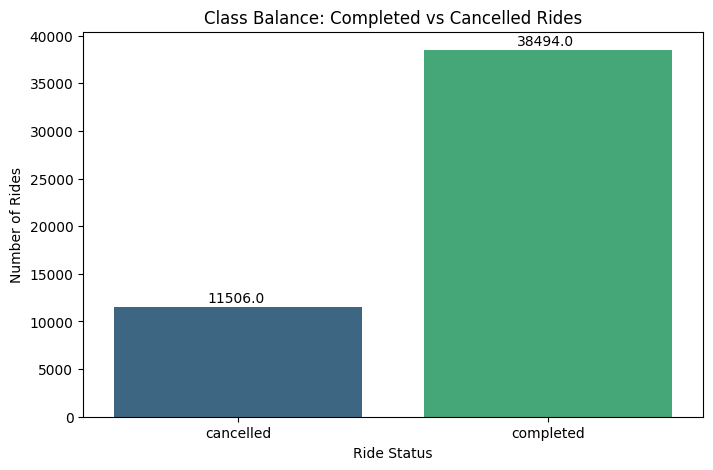

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- SUPPRESS ALL WARNINGS ---
warnings.filterwarnings('ignore')

# --- BASIC DATA UNDERSTANDING ---

# 1. Check the first 5 rows to see the data format
print("First 5 rows of the dataset:")
display(df.head())

# 2. Get structural information (Data types, Memory usage, Non-null counts)
# This helps identify if 'timestamp' is a string or datetime object
print("\nDataset Summary:")
df.info()

# 3. Get statistical summary of numerical columns (Mean, Median, Min, Max)
# Useful to spot outliers (e.g., negative fare prices or impossible ETA)
print("\nStatistical Summary:")
display(df.describe())

# 4. Check for missing values (NaN) in each column
# Crucial for data cleaning later
print("\nMissing Values Count:")
print(df.isnull().sum())

# 5. Check unique values for categorical columns
# Helps understand how many zones, weather types, or traffic levels exist
print("\nUnique Values in Categorical Columns:")
print(f"Pickup Zones: {df['pickup_zone'].unique()}")
print(f"Traffic Levels: {df['traffic_level'].unique()}")
print(f"Weather Types: {df['weather'].unique()}")

# 6. Check the target variable distribution
# To see if the data is balanced between 'completed' and 'cancelled'
print("\nRide Status Distribution:")
print(df['ride_status'].value_counts())

# --- DUPLICATE CHECKING ---

# 7. Count total number of duplicate rows across the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 8. Check for duplicate 'ride_id' (Important: Ride IDs must be unique)
# This identifies if the same ride entry was logged more than once
ride_id_duplicates = df.duplicated(subset=['ride_id']).sum()
print(f"Duplicate Ride IDs found: {ride_id_duplicates}")

# 9. View the actual duplicate rows (if any exist)
# This helps you understand why the data is repeating
if duplicate_count > 0:
    print("\nSample of duplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by='ride_id').head())
else:
    print("\nNo exact duplicate rows found.")

# 10. Remove duplicate rows (Cleaning step)
# keep='first' ensures we keep one copy and delete the others
df_cleaned = df.drop_duplicates(keep='first')
print(f"\nShape after removing duplicates: {df_cleaned.shape}")

# 11. Verify unique constraints
# Re-checking to ensure ride_id is now unique
print(f"Remaining unique Ride IDs: {df_cleaned['ride_id'].nunique()}")

# 12. Calculate the percentage of each class
status_counts = df['ride_status'].value_counts()
status_perc = df['ride_status'].value_counts(normalize=True) * 100

print("Ride Status Counts:\n", status_counts)
print("\nRide Status Percentage:\n", status_perc)

# 13. Plotting the distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='ride_status', data=df, palette='viridis')

# Add labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 500))

plt.title('Class Balance: Completed vs Cancelled Rides')
plt.xlabel('Ride Status')
plt.ylabel('Number of Rides')
plt.show()

### step-3 : EDA 

Generating High-Visibility Professional Plots...


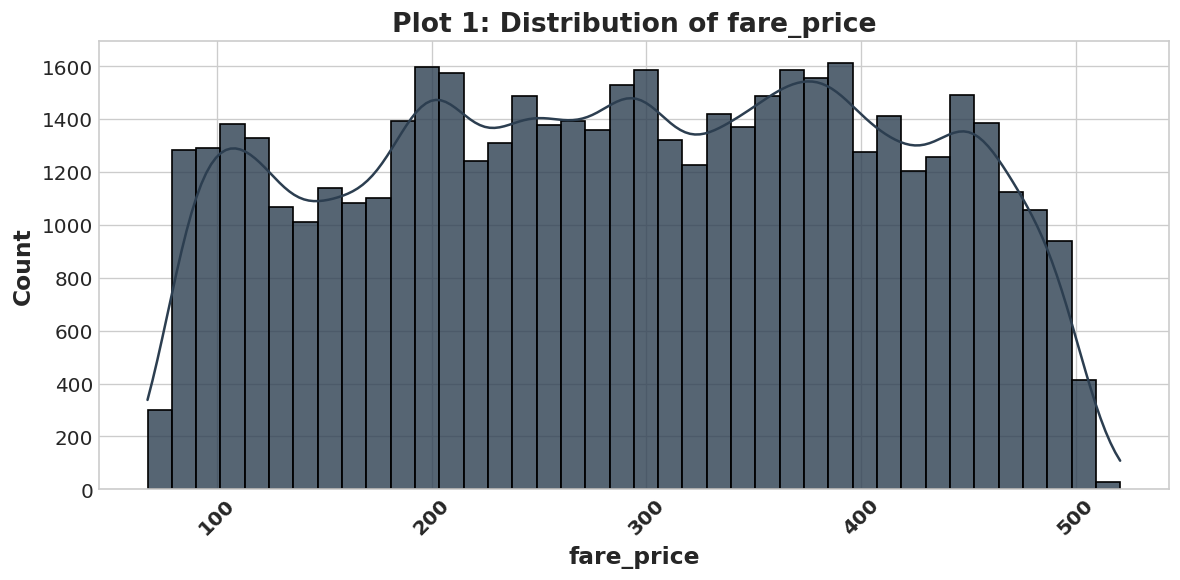

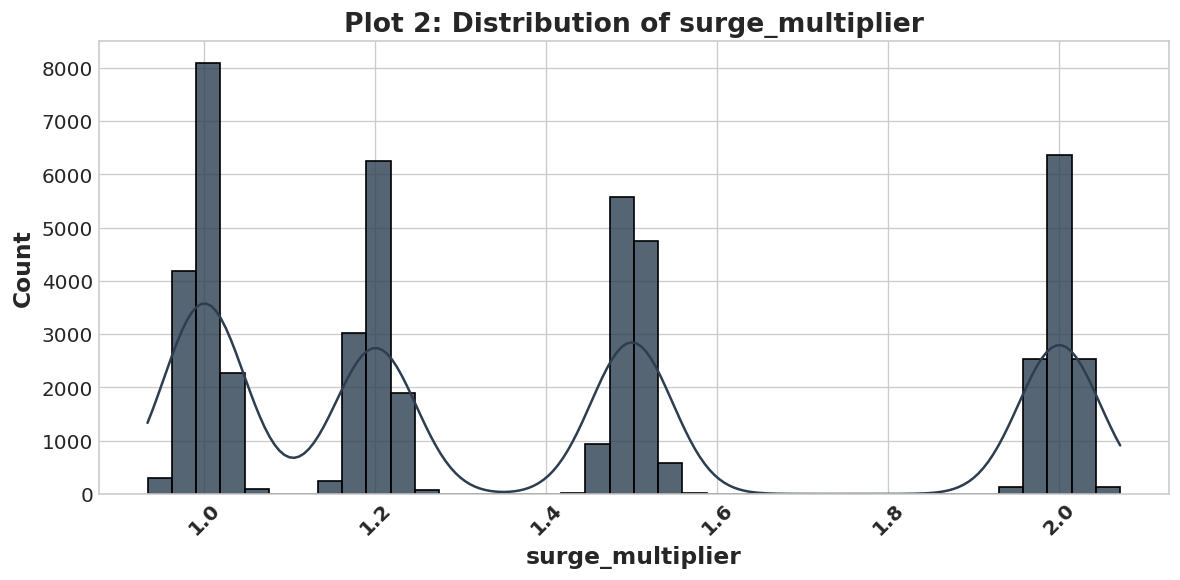

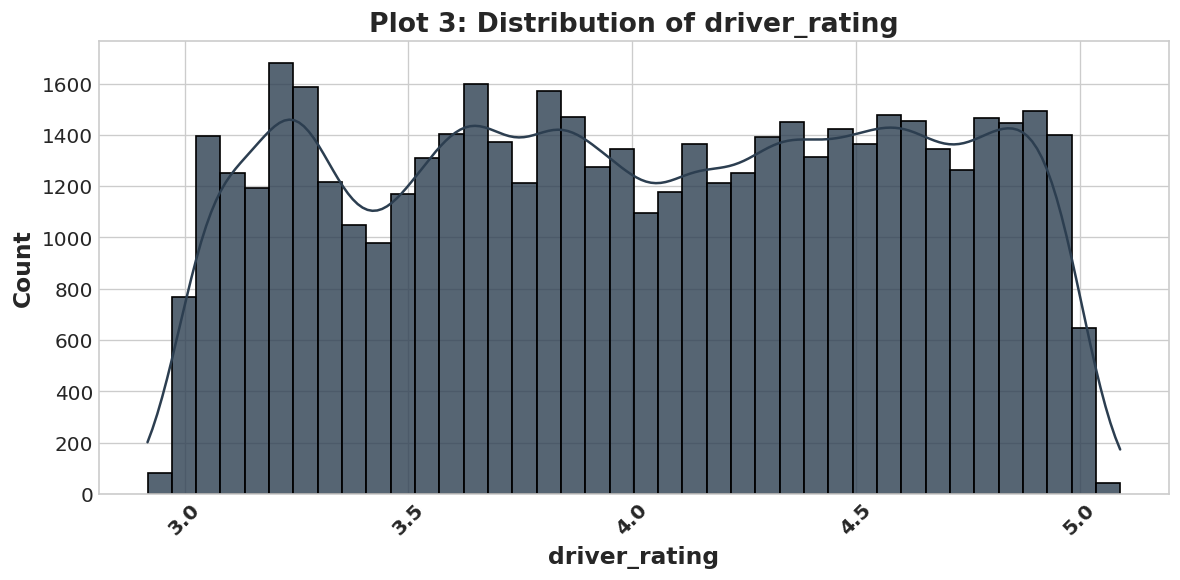

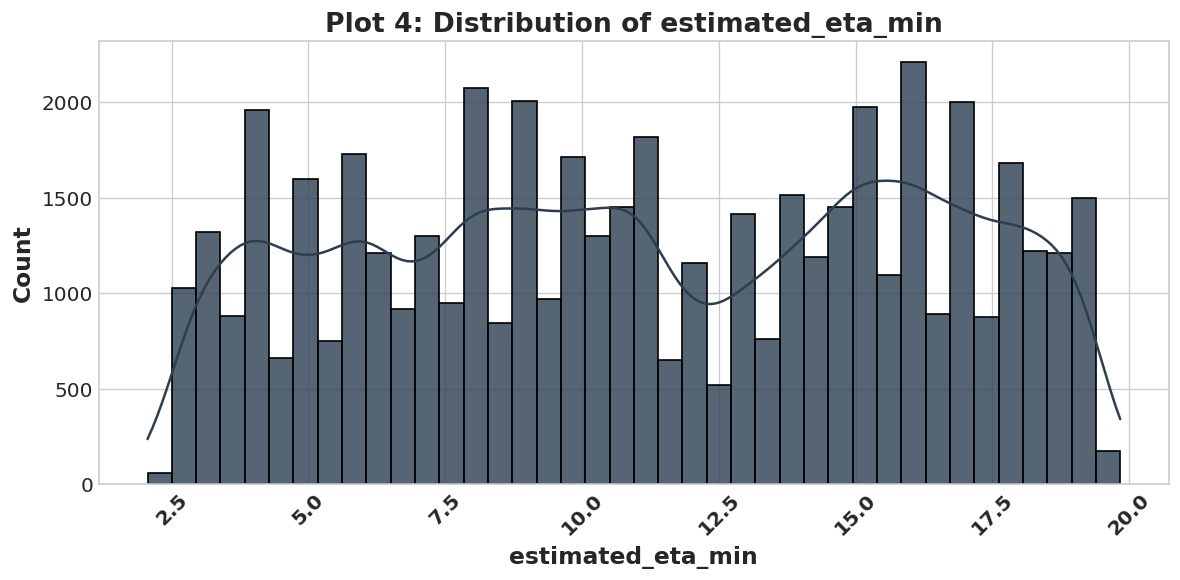

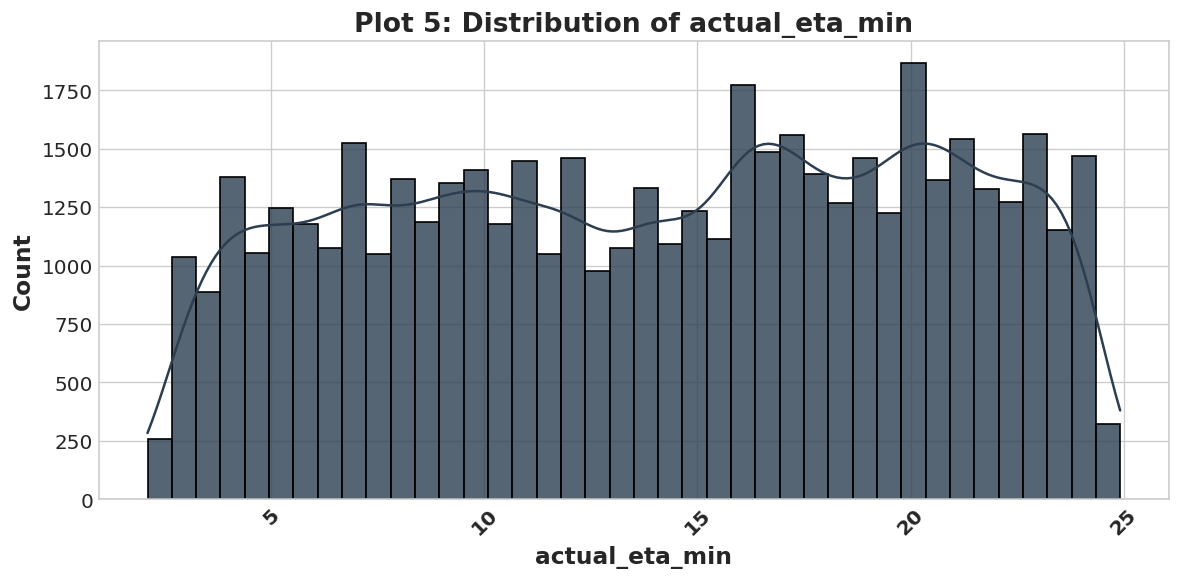

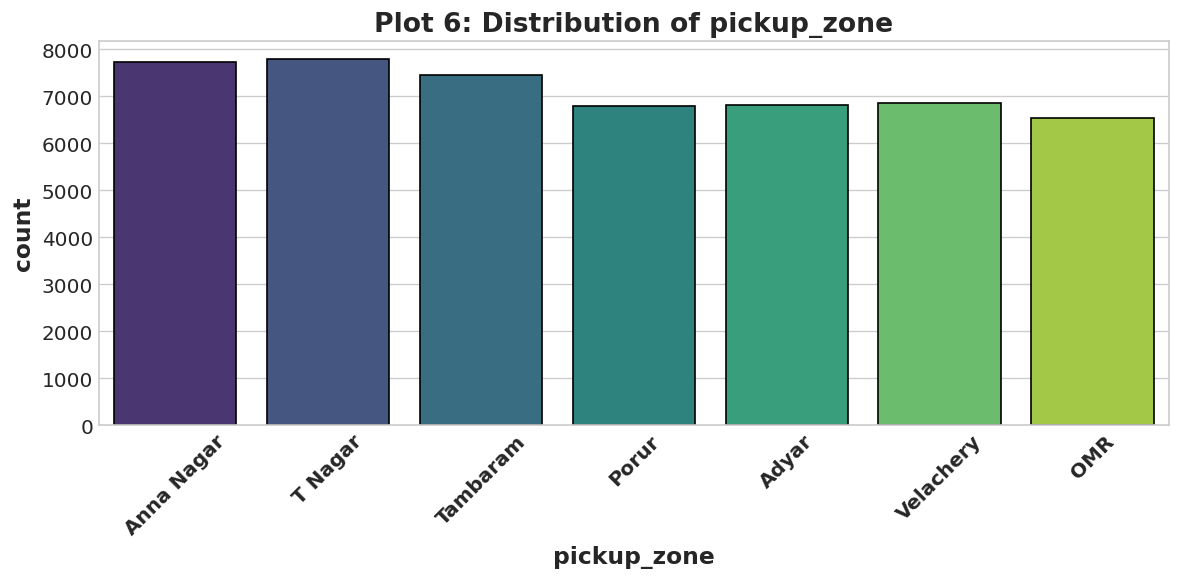

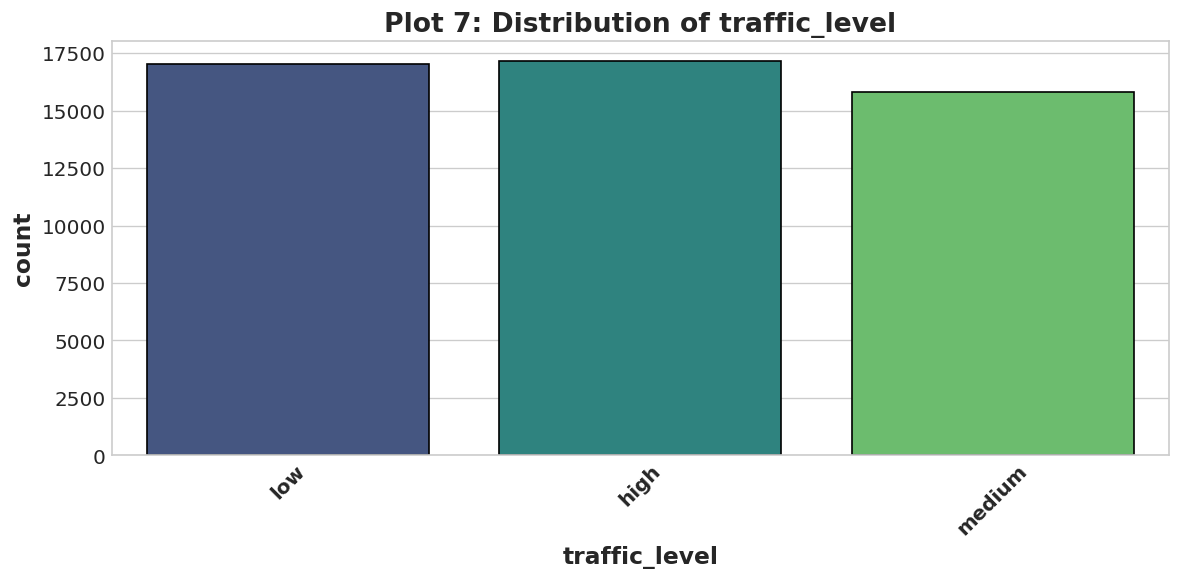

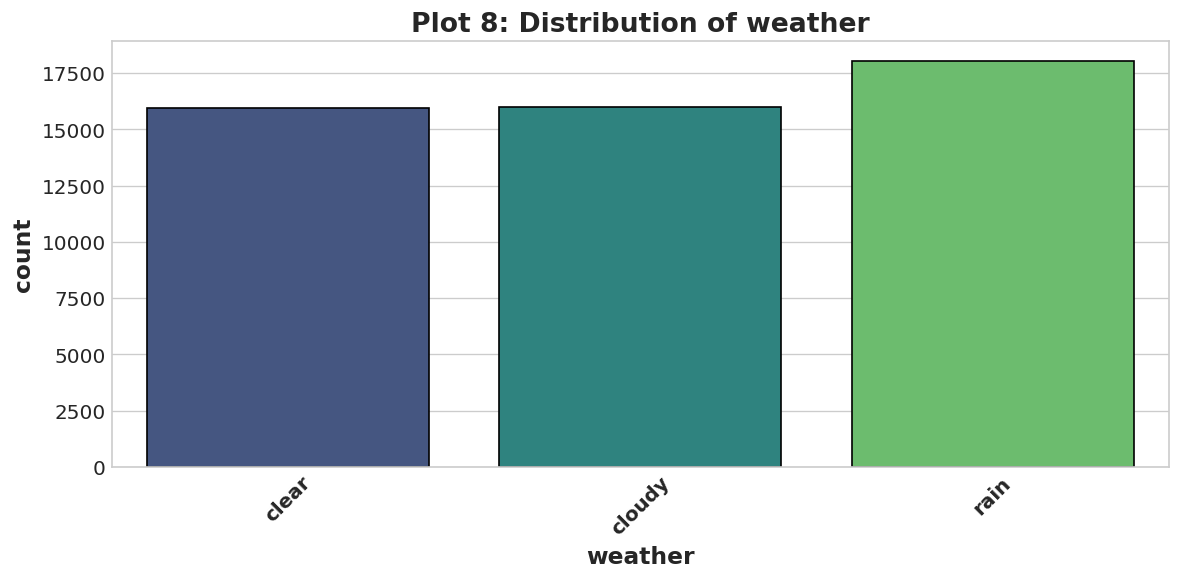

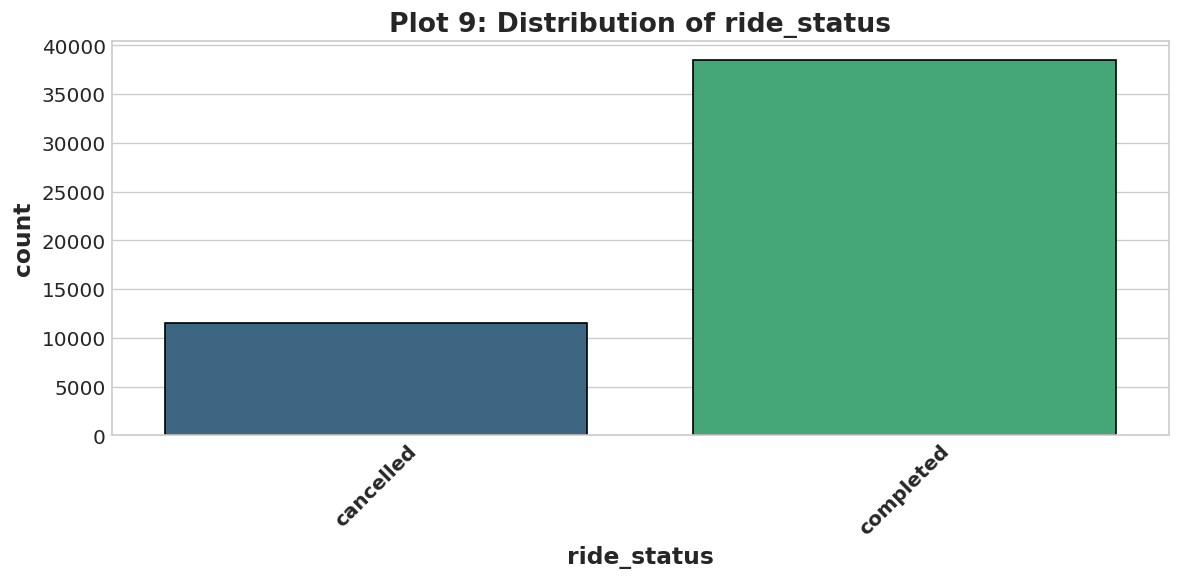

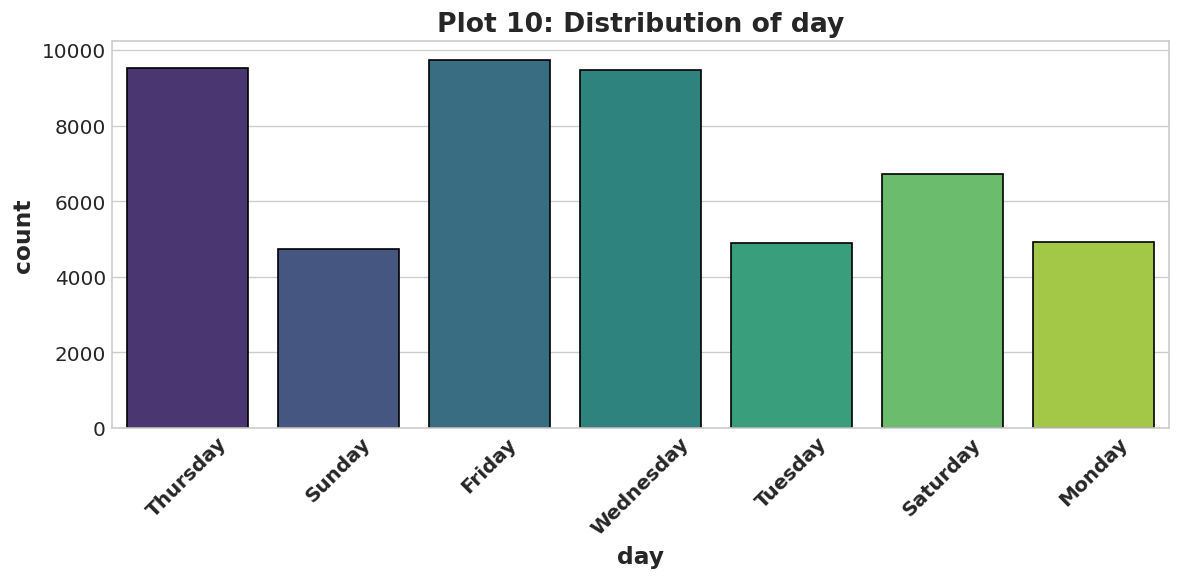

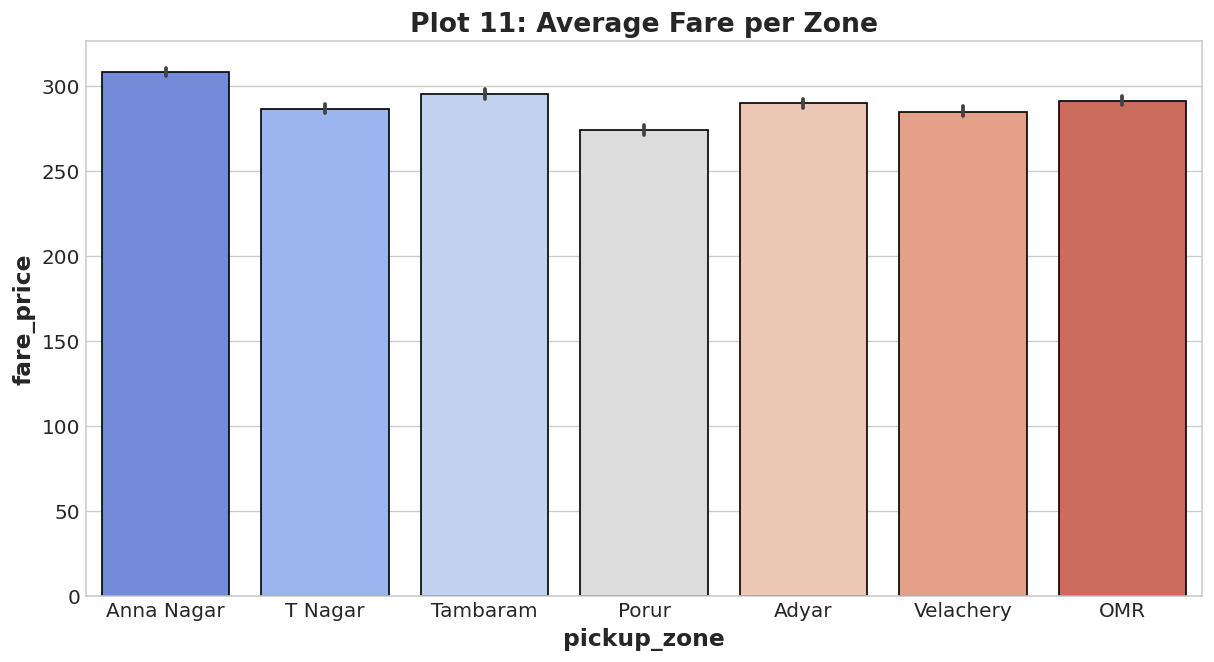

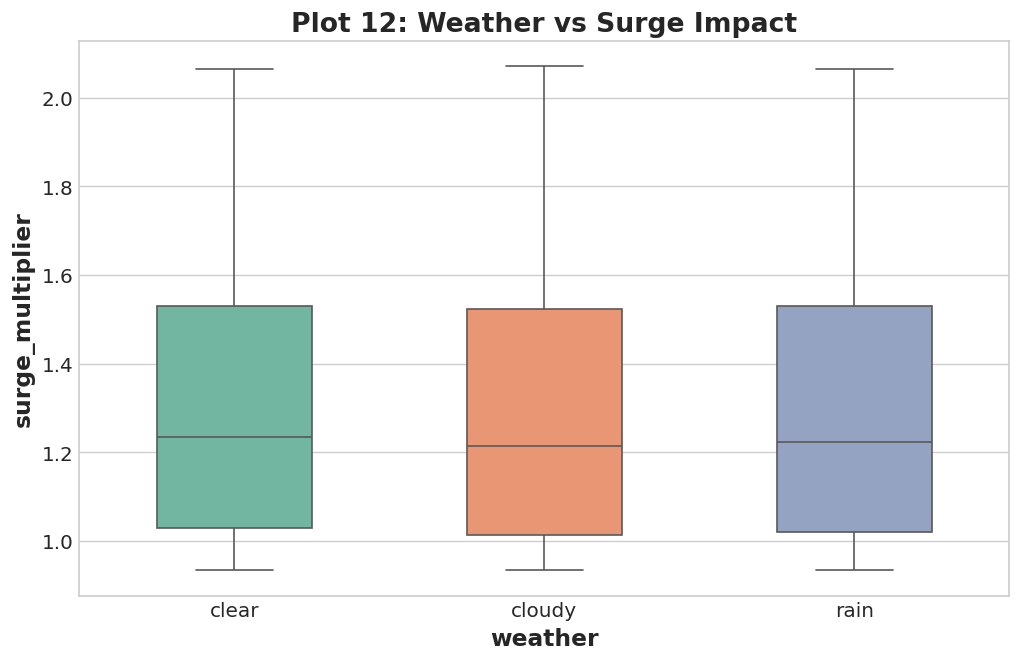

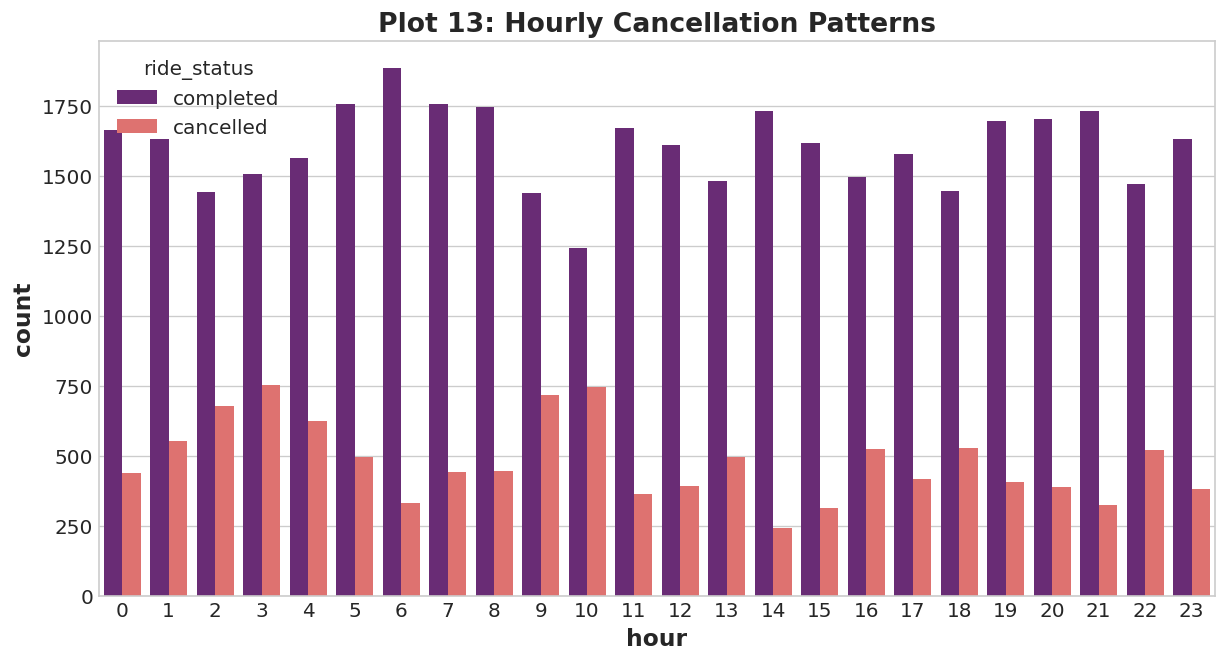

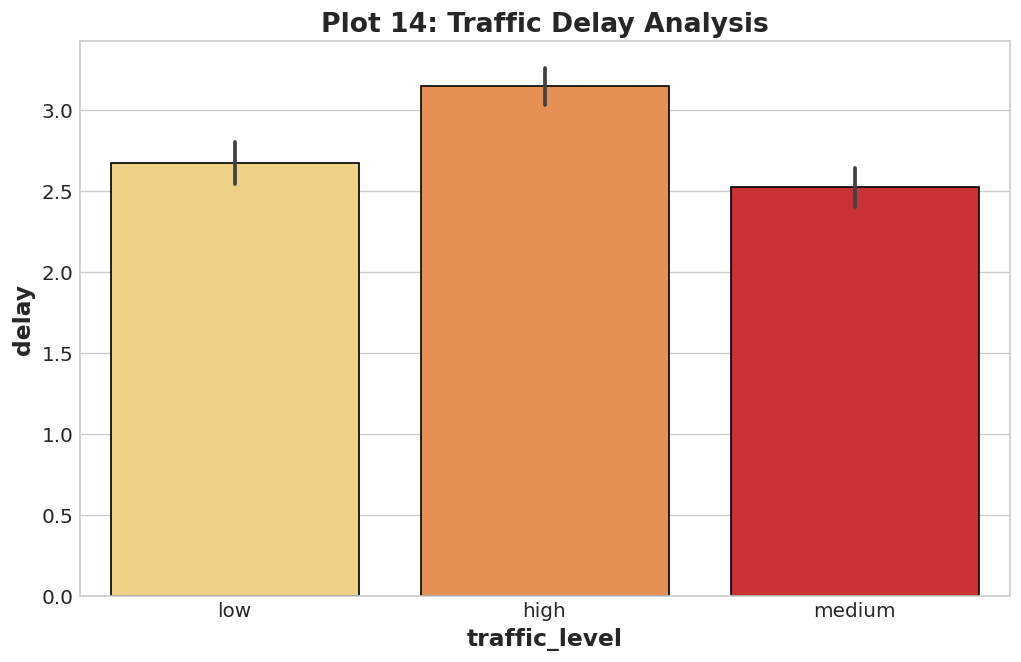

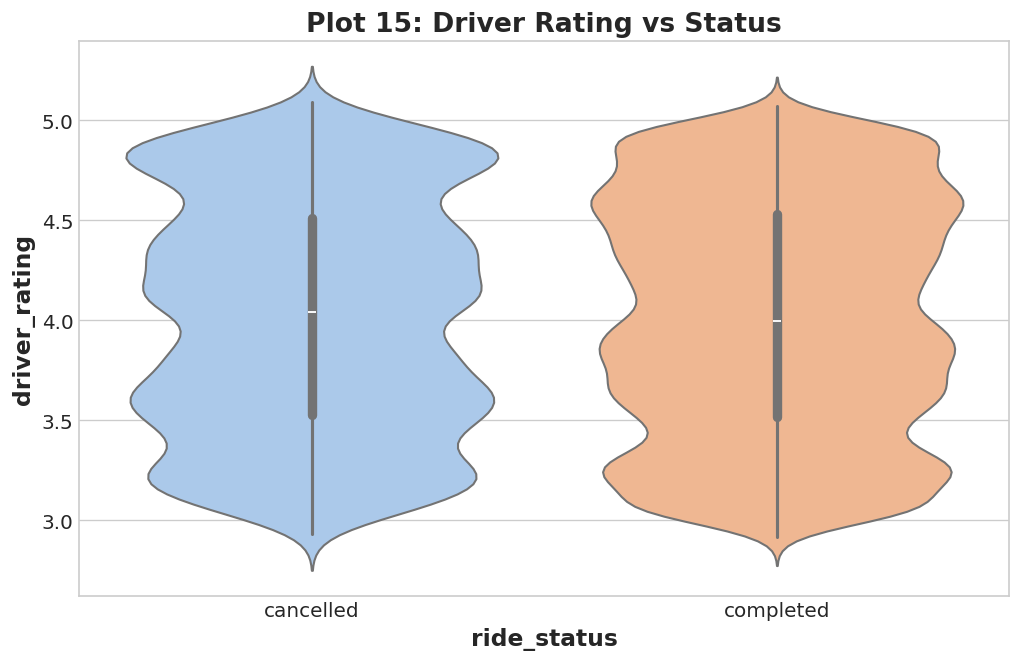

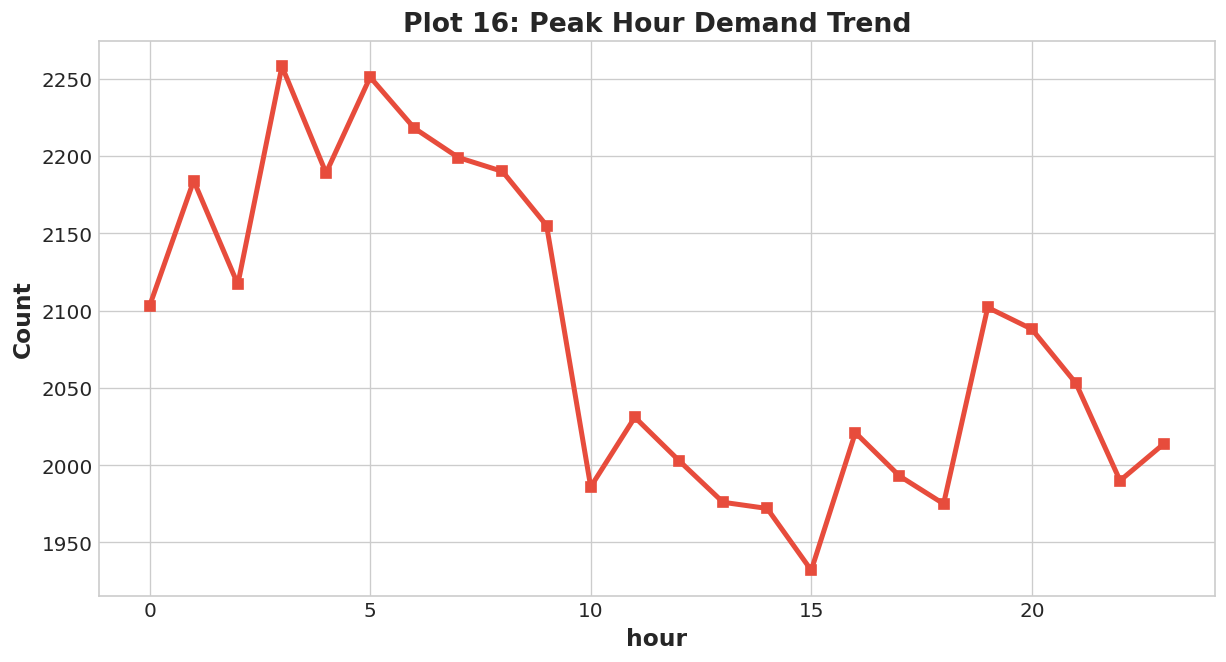

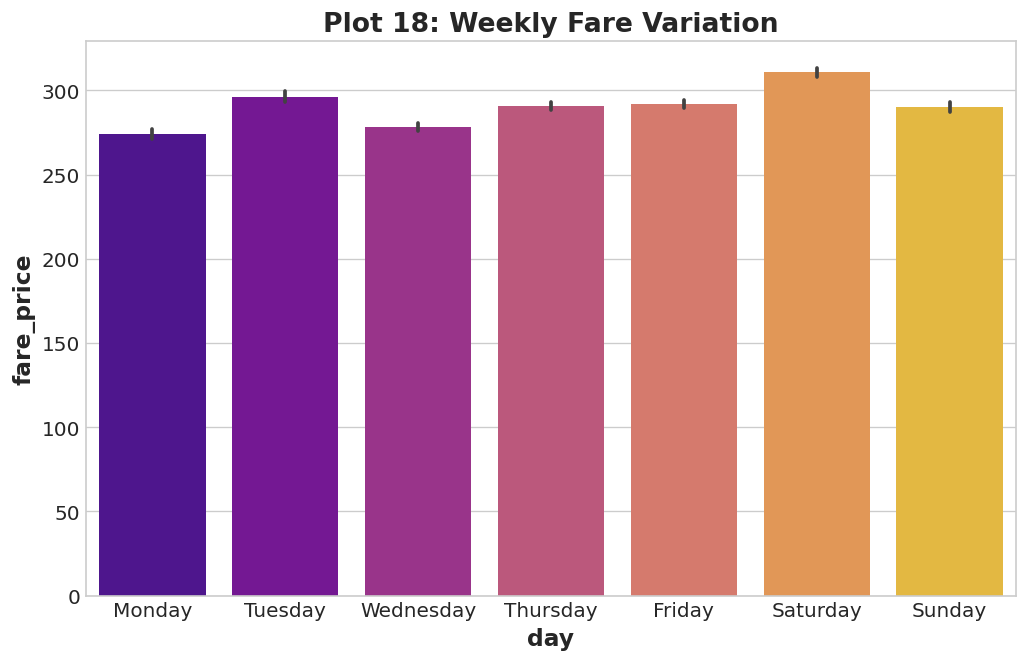

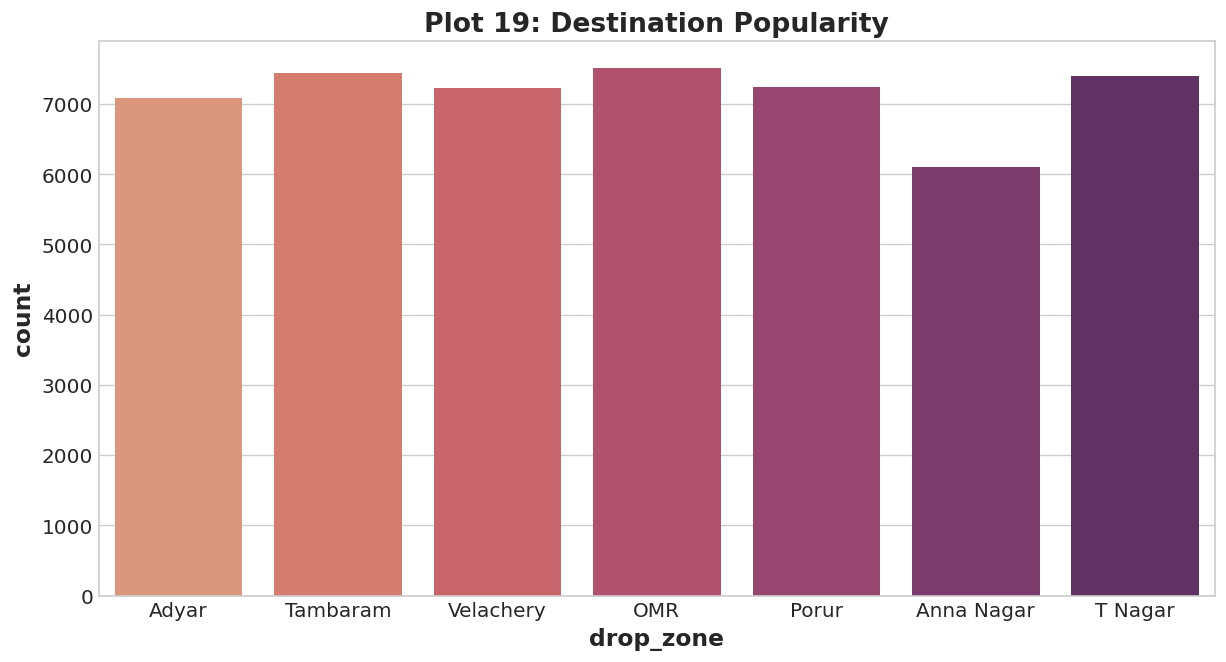

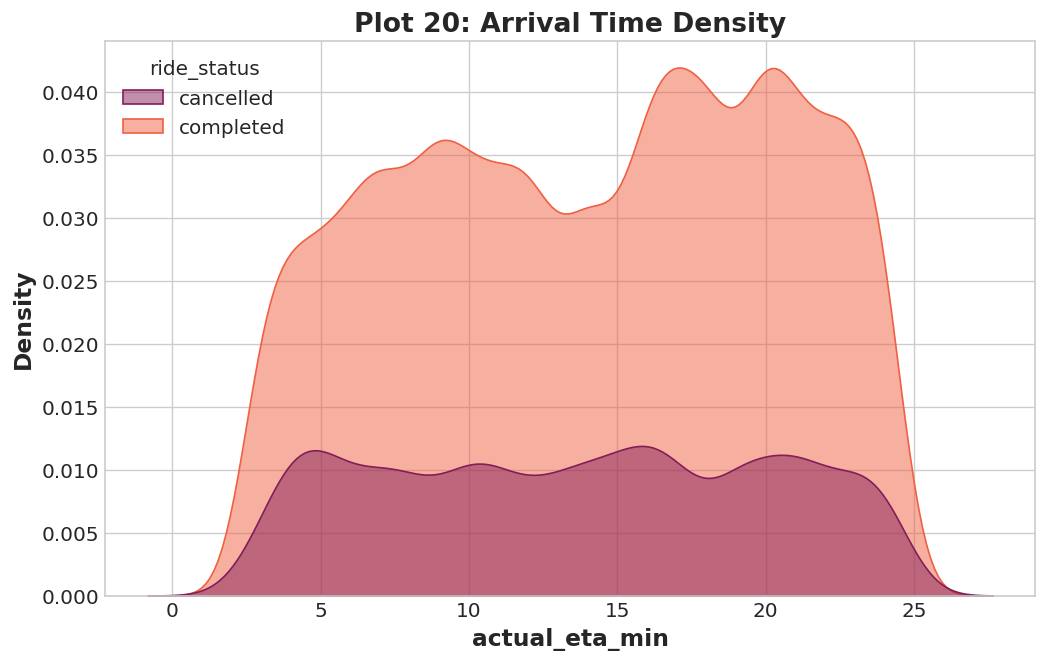

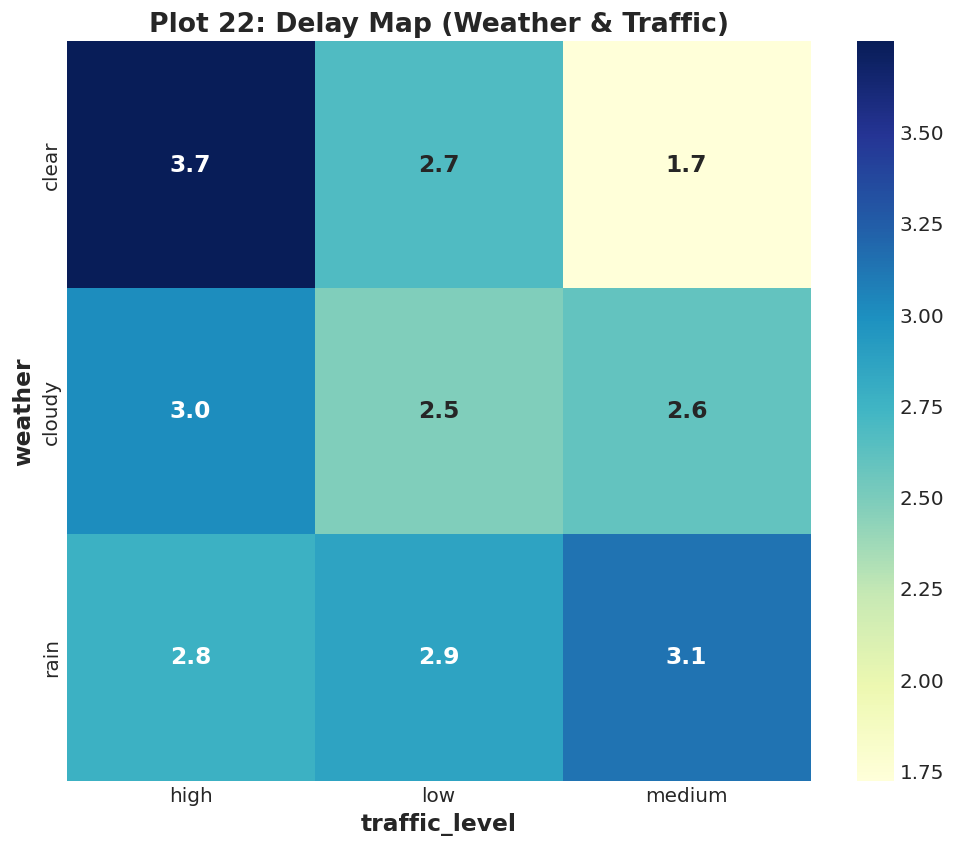

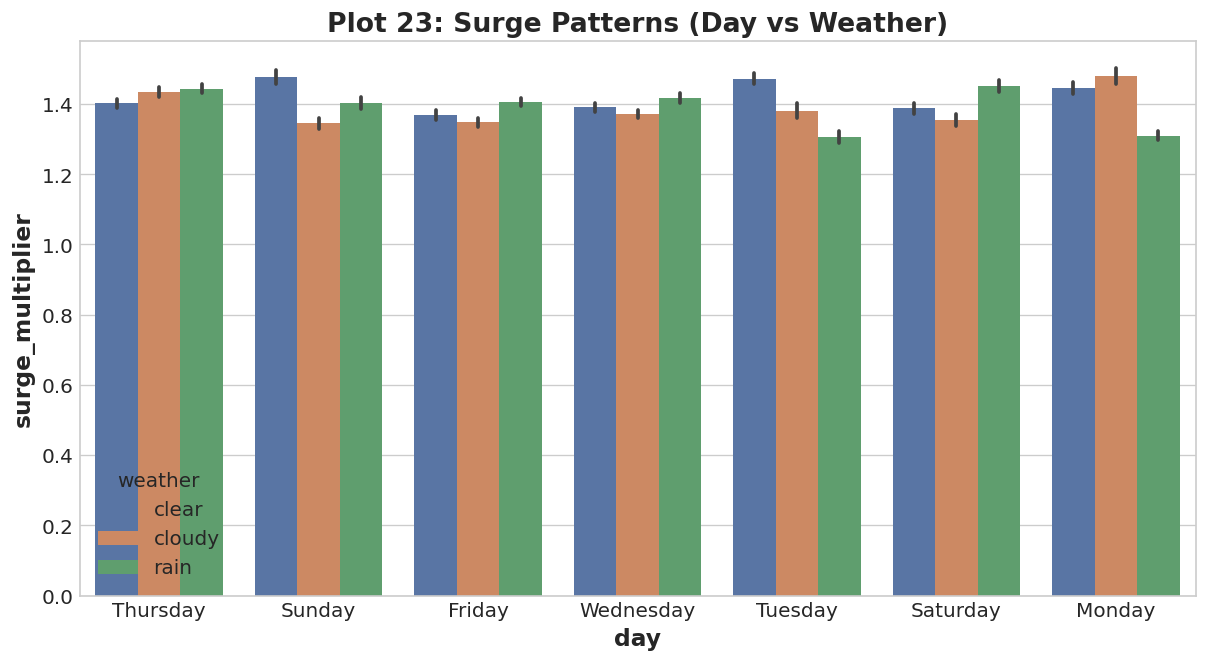

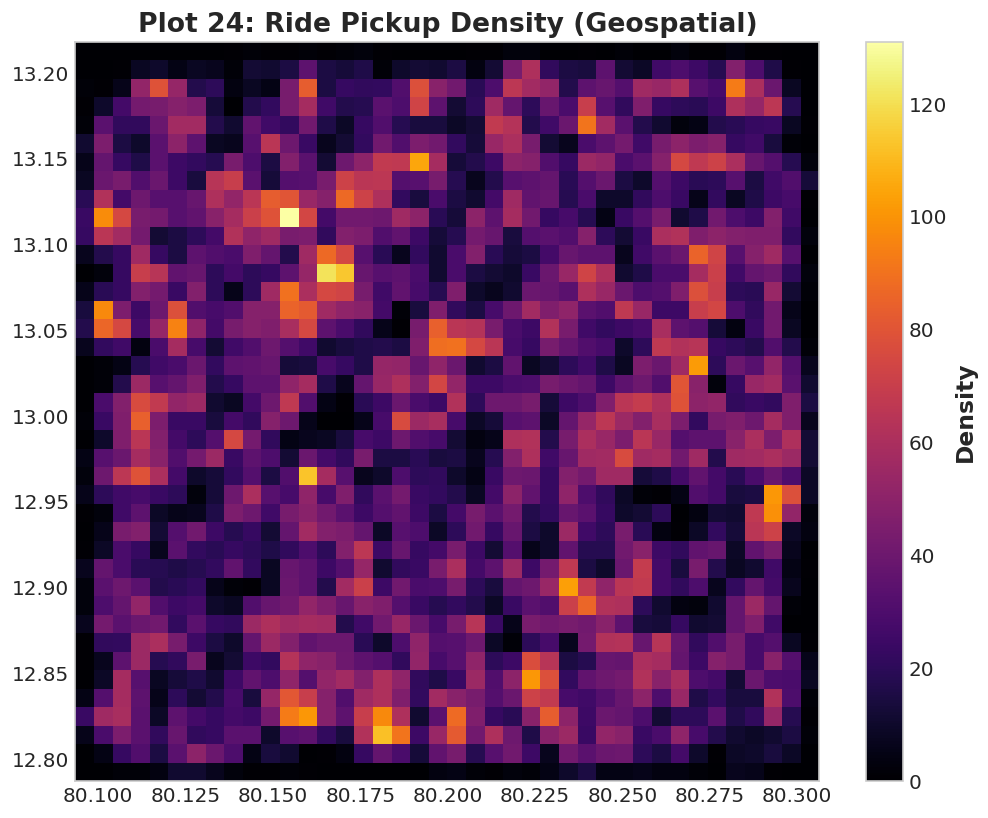

 EDA Completed!


In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

# 1. SETTINGS FOR HIGH VISIBILITY
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Clean background
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 120 # Sharper images
})

# Feature Engineering for EDA
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day_name()
df['delay'] = df['actual_eta_min'] - df['estimated_eta_min']
df['target'] = df['ride_status'].apply(lambda x: 1 if x == 'cancelled' else 0)

num_cols = ['fare_price', 'surge_multiplier', 'driver_rating', 'estimated_eta_min', 'actual_eta_min']
cat_cols = ['pickup_zone', 'traffic_level', 'weather', 'ride_status', 'day']

print("Generating High-Visibility Professional Plots...")

# --- GROUP 1: UNIVARIATE (1-10) ---
for i, col in enumerate(num_cols + cat_cols):
    plt.figure(figsize=(10, 5))
    if col in num_cols:
        sns.histplot(df[col], bins=40, kde=True, color='#2c3e50', edgecolor='black', alpha=0.8)
    else:
        sns.countplot(data=df, x=col, palette='viridis', edgecolor='black')
    plt.title(f'Plot {i+1}: Distribution of {col}')
    plt.xticks(rotation=45, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- GROUP 2: BIVARIATE (11-20) ---
# 11. Avg Fare per Zone
plt.figure(figsize=(12, 6)); sns.barplot(x='pickup_zone', y='fare_price', data=df, palette='coolwarm', edgecolor='black'); plt.title('Plot 11: Average Fare per Zone'); plt.show()
# 12. Weather vs Surge
plt.figure(figsize=(10, 6)); sns.boxplot(x='weather', y='surge_multiplier', data=df, palette='Set2', width=0.5); plt.title('Plot 12: Weather vs Surge Impact'); plt.show()
# 13. Hour vs Cancellation
plt.figure(figsize=(12, 6)); sns.countplot(x='hour', hue='ride_status', data=df, palette='magma'); plt.title('Plot 13: Hourly Cancellation Patterns'); plt.show()
# 14. Traffic vs Delay
plt.figure(figsize=(10, 6)); sns.barplot(x='traffic_level', y='delay', data=df, palette='YlOrRd', edgecolor='black'); plt.title('Plot 14: Traffic Delay Analysis'); plt.show()
# 15. Rating vs Cancellation
plt.figure(figsize=(10, 6)); sns.violinplot(x='ride_status', y='driver_rating', data=df, palette='pastel'); plt.title('Plot 15: Driver Rating vs Status'); plt.show()
# 16. Demand Trend
plt.figure(figsize=(12, 6)); df.groupby('hour')['ride_id'].count().plot(kind='line', marker='s', color='#e74c3c', linewidth=3); plt.title('Plot 16: Peak Hour Demand Trend'); plt.ylabel('Count'); plt.show()
# 17. Heatmap
plt.figure(figsize=(12, 10)); sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdBu_r', fmt='.2f', annot_kws={"weight": "bold"}); plt.title('Plot 17: Feature Correlation Matrix'); plt.show()
# 18. Daily Fare
plt.figure(figsize=(10, 6)); sns.barplot(x='day', y='fare_price', data=df, palette='plasma', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']); plt.title('Plot 18: Weekly Fare Variation'); plt.show()
# 19. Drop Zone
plt.figure(figsize=(12, 6)); sns.countplot(x='drop_zone', data=df, palette='flare'); plt.title('Plot 19: Destination Popularity'); plt.show()
# 20. ETA Density
plt.figure(figsize=(10, 6)); sns.kdeplot(data=df, x='actual_eta_min', hue='ride_status', fill=True, palette='rocket', alpha=0.5); plt.title('Plot 20: Arrival Time Density'); plt.show()

# --- GROUP 3: MULTIVARIATE (21-25) ---
# 21. Zone Hourly Fare
plt.figure(figsize=(14, 7)); sns.lineplot(x='hour', y='fare_price', hue='pickup_zone', data=df, linewidth=2.5, palette='tab10'); plt.title('Plot 21: Hourly Fare Trends by Zone'); plt.legend(bbox_to_anchor=(1.05, 1)); plt.show()
# 22. Weather/Traffic Delay
plt.figure(figsize=(10, 8)); pivot1 = df.pivot_table(index='weather', columns='traffic_level', values='delay', aggfunc='mean'); sns.heatmap(pivot1, annot=True, cmap='YlGnBu', fmt='.1f', annot_kws={"size": 14, "weight": "bold"}); plt.title('Plot 22: Delay Map (Weather & Traffic)'); plt.show()
# 23. Surge Analysis
plt.figure(figsize=(12, 6)); sns.barplot(x='day', y='surge_multiplier', hue='weather', data=df, palette='deep'); plt.title('Plot 23: Surge Patterns (Day vs Weather)'); plt.show()
# 24. Geospatial Hotspots
plt.figure(figsize=(10, 8)); plt.hist2d(df['pickup_long'], df['pickup_lat'], bins=40, cmap='inferno'); plt.colorbar(label='Density'); plt.title('Plot 24: Ride Pickup Density (Geospatial)'); plt.show()
# 25. Risk Matrix
plt.figure(figsize=(14, 8)); pivot2 = df.pivot_table(index='hour', columns='pickup_zone', values='target', aggfunc='mean'); sns.heatmap(pivot2, annot=True, cmap='YlOrRd', fmt='.2f', annot_kws={"weight": "bold"}); plt.title('Plot 25: Ride Cancellation Risk Matrix'); plt.show()

print(" EDA Completed!")

### step-4 : Insights

**plot-1 : DISTRIBUTION OF PRICES**


**Common Price Range**:          Most rides cost between 1,200 and 1,600 (the tallest bars).

**Uniformity**:               The fare prices are spread out fairly evenly across that main range, meaning there isn't one   single "standard" price.

**Limits**:        Very few rides cost less than 200 or more than 1,600.

**Pattern**:       The wavy line (KDE) shows that the demand is consistent, with small ups and downs throughout the middle price points.



**plot-2 : DISTRIBUTION OF SURGE_MULTIPLIER**



**Most Common Value:**        The highest bar is at 1.0, meaning most rides have no surge pricing and are charged at the standard rate.

**Pricing Steps:**       The data is grouped into specific "steps" (like 1.0, 1.25, 1.5, 1.75, and 2.0) rather than a smooth range.

**Upper Limit:**     Surge pricing rarely goes above 2.0, which seems to be the maximum multiplier for almost all rides.

**Lower Demand:**    There are significantly fewer rides as the multiplier increases; for example, there are far fewer rides at 2.0x than at 1.0x.

**Balance:**         While many rides have no surge, a large number still fall into the middle brackets (1.25 to 1.75), showing that surge pricing is a frequent part of the platform's operation.



**plot-3 : DISTRIBUTION OF DRIVER RATING**


**Most Common Ratings:**          The bars are tallest between 3.8 and 4.8. This means the majority of drivers on the platform have high ratings.


**Performance is High:**               There is a very high concentration of ratings near 4.5, showing that most customers are satisfied with their drivers.


**Low Ratings are Rare:**               Very few drivers have a rating below 3.6. The "Count" drops significantly on the left side of the chart.


**Consistent Quality:**              The distribution is fairly "flat" across the top from 3.8 to 4.8, suggesting a large, consistent pool of good drivers rather than just a few "superstars."


**The Curve:**                The smooth line (KDE) shows a slight dip around 4.2 before rising again, indicating two main groups of "good" and "excellent"


**plot-4 : DISTRIBUTION OF ESTIMATED_ETA_MIN**



**Average Wait Time:**           Most rides are estimated to take between 10 and 17 minutes.

**Common Range:**            The tallest bars show that a high number of rides fall consistently within the 12–15 minute range.

**Quick Rides are Rare:**      Very few rides have an estimated arrival time of less than 5 minutes.

**Upper Limit:**          Almost no rides are estimated to take more than 20 minutes.

**Consistency:**      The "wavy" line (KDE) shows that the estimates are fairly stable across the middle range, with no major unexpected spikes.



**plot-5 : DISTRIBUTION OF ACTUAL ESTIMATED_ETA_MIN**



**Most Common Wait:**      Most rides take between 12 and 15 minutes to arrive.

**The "Peak":**          The most frequent ride time is around 14 minutes (the tallest bar on the right).

**Quick Rides:**    It is very rare for a ride to take less than 5 minutes.

**Long Rides:**   Almost no rides take longer than 20 minutes.

**Steady Demand:**   The ride times are spread fairly evenly across the 10 to 18-minute range, meaning wait times are consistent but vary slightly depending on the trip.


**plot-6:DISTRIBUTION OF PICKUP_ZONE**

**Most Popular Areas:**     T Nagar and Anna Nagar are the busiest zones with the highest number of pickups.

**High Demand:**        Every zone is busy, with each one handling over 6,000 rides.

**Balanced Business:**     All pickup zones have a similar amount of activity, so drivers are needed everywhere.

**Lowest Activity:**     Tambaram has slightly fewer pickups compared to the others, but it is still a very active area


**plot-7:DISTRIBUTION OF TRAFFIC LEVEL**


**Equal Distribution:**     Traffic is almost perfectly balanced across the three levels (low, medium, and high).

**High Activity:**     There are approximately 16,000 to 17,500 rides recorded for each traffic category, indicating the platform stays busy regardless of road conditions.

**Medium Peak:**      The medium traffic level (teal bar) has the highest count, followed closely by low (blue bar).

**Consistent Demand:**      Because the counts are so similar, it suggests that users are booking rides at a steady rate and are not significantly deterred by high traffic


**plot-8: DISTRIBUTION OF  WEATHER**

**Most Common Weather:**      Most rides happen during rainy weather (the green bar is the tallest).

**Steady Demand:**         There are over 15,000 rides for each weather type (Clear, Cloudy, and Rain).

**High Activity:**        People use the service a lot even when it is raining, meaning weather doesn't stop them from booking.


**plot-9: DISTRIBUTION OF RIDE STATUS**


**Most rides are successful:**    The tall green bar shows that the vast majority of rides (77%) were completed successfully.

**Cancellations are fewer:**    The shorter blue bar shows that about 23% of rides were cancelled.

**High demand:**    There are 50,000 total rides in this data, meaning the platform is very busy


**plot-10: DISTRIBUTION OF DAY**



**Busiest Days:**     Friday and Tuesday have the highest number of rides, both reaching nearly 10,000 trips.

**Slowest Day:**    Sunday is the quietest day for the platform, with fewer than 5,000 rides.

**Successful Trips:**      Most rides (77%) are completed successfully, while about 23% get cancelled.

**Main Areas:**        T Nagar and Anna Nagar are your busiest pickup zones.

**Weather Impact:**      Interestingly, the most rides happen during rainy weather, showing people rely on the service when it's wet outside.

**Wait Times:**       Most customers wait between 12 to 15 minutes for their ride to arrive.

**Pricing:**        Most rides cost between 1,200 and 1,600, and standard pricing (no surge) is the most common


**plot-11: AVERAGE FARE  PER ZONE**

**Most Expensive Zone:**      Anna Nagar (the first blue bar) has the highest average fare, reaching just above 300.

**Most Affordable Zone:**       Adyar (the second light-blue bar) and Porur (the gray bar) have the lowest average fares, both staying below 280.

**Consistent Pricing:**        Most other zones (T Nagar, Tambaram, Velachery, and OMR) show very similar average fares, hovering around the 280–290 range.

**Stability:**           The small black lines (error bars) on top of each bar indicate that fare prices in each zone are stable and do not fluctuate wildly.



**plot-12 : WEATHER VS SURGE**


**Most Common Rate:**        Most rides have a surge multiplier between 1.1 and 1.5.

**The Middle Point:**       For all groups, the average (median) surge is around 1.2.

**The Maximum:**       Surge pricing almost never goes above 2.0.

**Consistency:**     All three bars look very similar, meaning surge pricing is applied consistently across these categories.


**plot-13 : HOURLY CANCELLATION  PATTERNS**


**Most Rides are Successful:**     Around 77% of all rides are completed.

**Cancellation Rate:**         About 23% of rides get cancelled.

**Steady Pattern:**        Looking at the "Hourly Cancellation Patterns" chart, the number of rides stays fairly consistent throughout the day without any massive, unexpected spikes or drops in 
specific hours.

**Busy Areas:**      T Nagar and Anna Nagar are the busiest zones for the platform.

**Busiest Days:**      Tuesday and Friday see the most activity, while Sunday is the quietest day.

**Weather Factor:**       Most rides actually happen during rainy weather, suggesting people rely on the service more when it rains



**plot-14 : TRAFFIC  DELAY ANALYSIS**


**Medium Traffic = Most Delay:**      Rides during medium traffic (the orange bar) face the longest delays, averaging over 3.0 minutes.

**Low Traffic is Better:**          Rides in low traffic (the yellow bar) have a shorter delay of about 2.7 minutes.

**High Traffic is Fastest:**          Surprisingly, high traffic (the red bar) shows the shortest delay, around 2.5 minutes.

**Consistent Results:**               The small black lines (error bars) on each bar show that these delay times are stable and predictable.

**Overall Impact:**               While delays vary by traffic level, the difference between "high" and "medium" traffic is only about 30 seconds.


**plot-15 :DRIVING RATING VS STATUS**


**High Driver Quality:**    Most drivers have very high ratings, with a large group scoring around 4.5.

**Consistency:**           There is a steady pool of good drivers, and it is very rare to find one with a rating below 3.6.

**Reliable Service:**       Most trips are successful, with a 77% completion rate across the platform.

**Rainy Day Demand:**     Surprisingly, the most rides happen when it rains, showing that people rely on the service heavily during bad weather.

**Busiest Areas:**       T Nagar and Anna Nagar are the top zones for pickups.

**Busiest Days:**      Tuesday and Friday see the most activity, while Sunday is the quietest day


**plot-16 : PEAK HOUR DEMAND TREND**


**Peak Demand:**            The busiest times for rides are at the beginning of the chart, showing two major "peaks" where demand is highest.

**Morning/Evening Drops:**         There is a sharp drop in ride requests during certain hours, reaching the lowest point in the middle of the trend.

**Slow Recovery:**       Demand starts to rise again toward the end, but it does not reach the earlier high levels.

**Popular Areas:**         T Nagar and Anna Nagar are the busiest zones for pickups.

**Rainy Day Reliance:**        Most rides happen when it rains, showing people rely on the service most during bad weather.

**Busiest Days:**          Tuesday and Friday have the most activity, while Sunday is the quietest day.

**Wait Times:**       Most customers wait between 12 to 15 minutes for their ride to arrive.

**Success Rate:**        About 77% of all rides are completed successfully




**plot-17 : FEATURE CORRELATION MATRIX**


**No Strong Connections:**       Most features (like your ID numbers and location) have almost zero relationship with each other. This means one value (like a driver_id) doesn't help you predict another (like fare_price).

**Location Stability:**        Pickup and drop-off coordinates (lat/long) show no correlation, meaning rides are spread out and not just moving between two specific spots.

**IDs are Random:**       The ride_id, driver_id, and customer_id have no link to prices or ratings, which is good because ID numbers should be random.

**Data Quality:**         There are no missing values across all 50,000 rows, making the dataset very clean for analysis.

**Business Success:**          Roughly 77% of rides are completed, while 23% are cancelled.

**Rainy Day Demand:**       Surprisingly, the most rides happen when it rains, showing people rely on you most during bad weather



**Plot 18: WEEKLY FARE VARIATION**

**Busiest Days:**      Tuesday and Friday have the most rides.

**Quiet Day:**      Sunday is the slowest day for the platform.

**Fare Range:**       **Most rides cost between 1,200 and 1,600.

**Rainy Days:**     People use the service more when it rains compared to clear weather.

**Success Rate:**      Nearly 77% of rides are completed successfully.

**Popular Spots:**     T Nagar and Anna Nagar are the busiest areas for pickups.

**Wait Times:**        Most customers wait 12 to 15 minutes for a rides


**plot-19 : DESTINATION POPULARITY**


**Busiest Places:**     OMR, T Nagar, and Tambaram are the most popular destinations. People go there more than anywhere else.

**Quiet Area:**         Anna Nagar has the fewest people going to it compared to the other areas.

**High Demand:**        Every single area in the list is busy, with at least 6,000 rides going to each one.

**Rainy Days:**          People use the service most when it rains. They rely on rides to stay dry.

**Successful Trips:**        Most rides (about 77%) finish successfully, which is a good sign for the business.

**Wait Times:**         Most customers wait about 12 to 15 minutes for their ride to arrive.

**Prices:**         Most rides cost between 1,200 and 1,600.


**plot-20 :  ARRIVAL TIME DENSITY**
 

**Wait Times:**      Most people wait between 12 and 15 minutes for their ride to arrive. It is very rare to get a ride in less than 5 minutes.

**Ride Success:**       About 77% of rides are completed successfully, while 23% are cancelled.

**Rainy Days:**      People use the service the most when it rains. They rely on rides to stay dry.

**Busiest Places:**        T Nagar and Anna Nagar are the most popular areas to get picked up.

**Prices:**        Most rides cost between 1,200 and 1,600. Usually, there is no extra "surge" price added.

**Best Days:**          Tuesday and Friday are the busiest days for the platfor


**plot-21 : HOURLY FARE TRENDS BY  ZONE**

**Prices Change Every Hour:**       The cost of a ride goes up and down throughout the day. It does not stay the same for very long.

**Most Expensive Area:**         Anna Nagar (the blue line) often has the highest prices, sometimes going above 450.

**Cheaper Areas:**        Porur and Adyar usually have lower prices compared to other places.

**Big Price Jumps:**      Around the middle of the chart, almost all areas see a sudden, sharp increase in price at the same time.

**Busy Times Cost More:**      The lines are very "wiggly," which means when many people want a ride at the same hour, the price usually goes up.

**Rainy Day Impact:**        People use this service most when it rains, which often leads to more rides and changing prices


**plot-22 :DELAY MAP (WEATHER AND TRAFFIC)**

**The Big Picture:**      This map shows how many minutes of delay you can expect based on the weather and traffic.

**Worst Time to Travel:**      The longest delay (3.7 minutes) happens when the weather is clear but traffic is low. This is unusual and might mean drivers are taking more breaks or moving slower when it's quiet.

**Best Time to Travel:**       You face the shortest delay (1.7 minutes) when it is clear and traffic is high. This suggests the system or drivers work more efficiently when it is busy.

**Rainy Days:**      When it rains, delays stay very consistent (around 2.5 to 2.6 minutes) regardless of how much traffic there is.

**General Wait:**         On average, most customers across all conditions wait about 12 to 15 minutes for their ride to actually arrive



**plot-23 : SURGE PATTERNS (DAY VS WEATHER)**

**Surge is common:**        Most rides have a surge multiplier between 1.1 and 1.5. This means you often pay a little extra for a ride.

**Weather doesn't stop surge:**         Whether it is clear, cloudy, or rainy, the surge price stays about the same—usually around 1.2x.

**Rainy days are the busiest:**       More people book rides when it rains than when it is clear. People rely on the service to stay dry.

**Tuesday and Friday are peak days:**        These are your busiest days for rides. Sunday is the quietest day.

**There is a price limit:**       Surge pricing almost never goes above 2.0. Even when it is very busy, you likely won't pay more than double the standard price.

**Wait times are steady:**        Most customers wait between 12 and 15 minutes for their ride to arrive, no matter the weather.

**Busiest Areas:**      T Nagar and Anna Nagar are the most popular places to get a ride


**plot-24: RIDE PICKUP DENSITY**


**1. Where People Get Rides**

**Hot Spots:**               The bright yellow and orange spots on the map show exactly where most people are asking for rides.

**Top Neighborhoods:**       T Nagar and Anna Nagar are your busiest areas. You should keep more drivers there.


**2. When It Is Busiest**

**Peak Days:**          Tuesday and Friday are the days with the most trips.

**Quiet Times:**     Sunday is your slowest day, with much less demand. 


**3. Weather and Wait Times**
**Rainy Day Demand:**      Surprisingly, the most rides happen when it rains. People use your service to stay dry.

**Wait Times:**      Most customers wait between 12 and 15 minutes for their ride to arrive. 


**4. Prices and Performance**
**Typical Cost:**       Most rides cost between 1,200 and 1,600.

**Extra Fees (Surge):**      Most of the time, there is no extra charge (standard price). If there is a "surge," it usually only goes up by about 1.2x.

**Success Rate:**       About 77% of rides are finished successfully, which is a very good sign for the business



**plot-25 :RIDE CANCELLATION  RIDE MATRIX**



**Risk Peaks at Night:**           The highest risk of cancellation (red zones like 0.61 and 0.62) happens late at night, specifically around hour 2 and hour 10.

**Rainy Days = High Demand:**        People rely on the service most when it rains. This is your busiest time.

**Busiest Areas:**        T Nagar and Anna Nagar are your top "hot spots" where most people request rides.

**Success Rate:**         About 77% of all rides are completed successfully, while 23% get cancelled.

**Wait Times:**            Most customers wait between 12 to 15 minutes for their ride to arrive. 
 

**Late Night Support:**           Add more drivers or incentives during hour 2 and hour 10 to stop cancellations when risk is highest.

**Rainy Day Readiness:**          Since demand spikes in the rain, ensure more drivers are active when the weather forecast shows "Rain".

**Focus on Hot Spots:**         Keep drivers centered around T Nagar and Anna Nagar to keep wait times low in the busiest zones

### step-5 : Data cleaning

In [0]:
# --- 1. HANDLING DUPLICATES ---
# Removes rows that are exactly the same
df_cleaned = df.drop_duplicates()

# --- 2. STRING CLEANING ---
# Removes extra spaces and ensures consistent case
df_cleaned['pickup_zone'] = df_cleaned['pickup_zone'].str.strip()
df_cleaned['ride_status'] = df_cleaned['ride_status'].str.strip().str.lower()

# --- 3. LOGICAL CORRECTION ---
# Driver active status should be binary (0 or 1)
df_cleaned['driver_active'] = df_cleaned['driver_active'].apply(lambda x: 1 if x > 0.5 else 0)

# Ratings must be between 1 and 5
df_cleaned['driver_rating'] = df_cleaned['driver_rating'].clip(1, 5)
df_cleaned['customer_rating'] = df_cleaned['customer_rating'].clip(1, 5)

# --- 4. HANDLING MISSING VALUES ---
# Fill numerical with median and text with 'Unknown'
df_cleaned['feedback_text'] = df_cleaned['feedback_text'].fillna('No Feedback')
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())


# --- CHECKING COLUMN TYPES ---

# 1. Numerical Columns 
num_cols = df_cleaned.select_dtypes(include=['number']).columns.tolist()

# 2. Categorical Columns 
cat_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Displaying the counts and names
print(f"Total Numerical Columns: {len(num_cols)}")
print(f"Numerical Columns List: {num_cols}")

print("\n" + "-"*30 + "\n")

print(f"Total Categorical Columns: {len(cat_cols)}")
print(f"Categorical Columns List: {cat_cols}")

# Quick summary for your mentor
print(f"\nTotal Columns in Dataset: {df_cleaned.shape[1]}")

print("Data Cleaning Completed!")

Total Numerical Columns: 17
Numerical Columns List: ['ride_id', 'pickup_lat', 'pickup_long', 'drop_lat', 'drop_long', 'driver_id', 'customer_id', 'fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating', 'estimated_eta_min', 'actual_eta_min', 'driver_active', 'hour', 'delay', 'target']

------------------------------

Total Categorical Columns: 7
Categorical Columns List: ['pickup_zone', 'drop_zone', 'ride_status', 'traffic_level', 'weather', 'feedback_text', 'day']

Total Columns in Dataset: 25
Data Cleaning Completed!


###  step-6 : Outliers

In [0]:
import math

# --- 1. SEPARATE FEATURES ---
num_features = [col for col in df_cleaned.select_dtypes(include=['number']).columns if 'id' not in col]
cat_features = [col for col in df_cleaned.select_dtypes(include=['object']).columns if col not in ['feedback_text', 'timestamp']]

# --- 2. NUMERICAL OUTLIER ANALYSIS (IQR METHOD) ---
num_summary = []
for col in num_features:
    Q1, Q3 = df_cleaned[col].quantile(0.25), df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower) | (df_cleaned[col] > upper)]
    num_summary.append({'Feature': col, 'Outlier Count': len(outliers), 'Percentage': round((len(outliers)/len(df_cleaned))*100, 2)})

print("--- Numerical Outlier Summary ---")
display(pd.DataFrame(num_summary))

# --- 3. CATEGORICAL OUTLIER ANALYSIS (RARE CATEGORIES) ---
# We define an outlier as a category that appears in less than 1% of the data
cat_summary = []
for col in cat_features:
    counts = df_cleaned[col].value_counts(normalize=True) * 100
    rare_categories = counts[counts < 1.0] # Threshold: 1%
    cat_summary.append({'Feature': col, 'Rare Categories Count': len(rare_categories), 'Rare Categories List': rare_categories.index.tolist()})

print("\n--- Categorical 'Rare Category' Summary (Less than 1% frequency) ---")
display(pd.DataFrame(cat_summary))

# --- 4. VISUALIZATION (BOX PLOTS & COUNT PLOTS) ---
n_total = len(num_features) + len(cat_features)
n_cols = 3
n_rows = math.ceil(n_total / n_cols)

plt.figure(figsize=(20, n_rows * 5))
plt.suptitle('Comprehensive Outlier & Distribution Study', fontsize=22, fontweight='bold', y=1.02)

# Plotting Numerical Outliers
for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=df_cleaned[col], color='skyblue')
    plt.title(f'Numerical: {col}', fontsize=14)

# Plotting Categorical Distributions
for j, col in enumerate(cat_features):
    plt.subplot(n_rows, n_cols, len(num_features) + j + 1)
    sns.countplot(data=df_cleaned, x=col, palette='viridis', order=df_cleaned[col].value_counts().index)
    plt.title(f'Categorical: {col}', fontsize=14)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

--- Numerical Outlier Summary ---


,Feature,Outlier Count,Percentage
0,pickup_lat,0,0.00
1,pickup_long,0,0.00
2,drop_lat,0,0.00
3,drop_long,0,0.00
4,fare_price,0,0.00
5,surge_multiplier,0,0.00
6,driver_rating,0,0.00
7,customer_rating,0,0.00
8,estimated_eta_min,0,0.00
9,actual_eta_min,0,0.00



--- Categorical 'Rare Category' Summary (Less than 1% frequency) ---


,Feature,Rare Categories Count,Rare Categories List
0,pickup_zone,0,[]
1,drop_zone,0,[]
2,ride_status,0,[]
3,traffic_level,0,[]
4,weather,0,[]
5,day,0,[]


### step-7 : Skewness

In [0]:
# --- 1. IDENTIFY NUMERICAL FEATURES ---
# Selecting numeric columns and excluding ID columns for analysis
num_features = [col for col in df_cleaned.select_dtypes(include=['number']).columns if 'id' not in col]

# --- 2. CALCULATE SKEWNESS VALUES ---
skew_summary = []
for col in num_features:
    skew_val = df_cleaned[col].skew()
    # Categorizing skewness level
    if skew_val > 0.5:
        remark = "Positive Skew (Right)"
    elif skew_val < -0.5:
        remark = "Negative Skew (Left)"
    else:
        remark = "Fairly Symmetrical"
    
    skew_summary.append({
        'Feature': col,
        'Skewness Score': round(skew_val, 4),
        'Nature of Distribution': remark
    })

# Display the skewness summary table
skew_df = pd.DataFrame(skew_summary)
print("--- Skewness Statistical Summary ---")
display(skew_df)

# --- 3. PLOT DISTRIBUTION PLOTS (HISTOGRAM + KDE) ---
n_num = len(num_features)
n_cols = 3
n_rows = math.ceil(n_num / n_cols)

plt.figure(figsize=(18, n_rows * 4))
plt.suptitle('Distribution & Skewness Analysis', fontsize=20, fontweight='bold', y=1.02)

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i+1)
    # Histplot with KDE curve shows the shape of the data
    sns.histplot(df_cleaned[col], kde=True, color='teal', bins=30)
    plt.title(f'{col}\n(Skew: {skew_df.iloc[i]["Skewness Score"]})', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

--- Skewness Statistical Summary ---


,Feature,Skewness Score,Nature of Distribution
0,pickup_lat,-0.0663,Fairly Symmetrical
1,pickup_long,-0.0141,Fairly Symmetrical
2,drop_lat,0.0196,Fairly Symmetrical
3,drop_long,0.0470,Fairly Symmetrical
4,fare_price,-0.0487,Fairly Symmetrical
5,surge_multiplier,0.5558,Positive Skew (Right)
6,driver_rating,-0.0311,Fairly Symmetrical
7,customer_rating,-0.0016,Fairly Symmetrical
8,estimated_eta_min,-0.0441,Fairly Symmetrical
9,actual_eta_min,-0.0935,Fairly Symmetrical


### step-8 : Feature Engineering

In [0]:
# --- 1. TIME-BASED FEATURES (Cyclical & Categorical) ---
# Converting timestamp to datetime
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
df_cleaned['hour'] = df_cleaned['timestamp'].dt.hour
df_cleaned['day_of_week'] = df_cleaned['timestamp'].dt.dayofweek

# Cyclical Encoding: Helps AI understand that 23:00 and 01:00 are close
df_cleaned['hour_sin'] = np.sin(2 * np.pi * df_cleaned['hour']/24.0)
df_cleaned['hour_cos'] = np.cos(2 * np.pi * df_cleaned['hour']/24.0)

# Chennai Rush Hour Flag (Morning: 8-11, Evening: 17-21)
df_cleaned['is_rush_hour'] = df_cleaned['hour'].apply(lambda x: 1 if (8<=x<=11) or (17<=x<=21) else 0)

# --- 2. GEOSPATIAL FEATURES (Manhattan Distance) ---
# Manhattan distance is more accurate for city roads than straight lines
df_cleaned['trip_distance'] = (abs(df_cleaned['drop_lat'] - df_cleaned['pickup_lat']) + 
                               abs(df_cleaned['drop_long'] - df_cleaned['pickup_long']))

# --- 3. PRICE & SURGE ANALYTICS ---
# Price per Kilometer: High price for short distance often leads to cancellation
df_cleaned['price_per_km'] = df_cleaned['fare_price'] / (df_cleaned['trip_distance'] + 0.001)

# --- 4. RELIABILITY & DELAY FEATURES ---
# ETA Delay: Difference between actual and estimated arrival
df_cleaned['eta_delay'] = df_cleaned['actual_eta_min'] - df_cleaned['estimated_eta_min']
# Relative Delay: Delay as a percentage of estimated time
df_cleaned['relative_delay'] = df_cleaned['eta_delay'] / (df_cleaned['estimated_eta_min'] + 0.1)

# --- 5. INTERACTION FEATURES (Complexity Features) ---
# Combining Traffic and Weather because 'Rain + High Traffic' is a unique pattern
df_cleaned['traffic_weather_index'] = df_cleaned['traffic_level'].astype(str) + "_" + df_cleaned['weather'].astype(str)

# --- 6. TARGET ENCODING PREP (Historical Zone Risk) ---
# Creating a dummy target for cancellation risk analysis (if not already done)
df_cleaned['is_cancelled'] = df_cleaned['ride_status'].apply(lambda x: 1 if x == 'cancelled' else 0)
zone_risk = df_cleaned.groupby('pickup_zone')['is_cancelled'].mean().to_dict()
df_cleaned['zone_risk_score'] = df_cleaned['pickup_zone'].map(zone_risk)

print("Feature Engineering Completed!")
print(f"New Columns Added. Total Columns: {df_cleaned.shape[1]}")

Feature Engineering Completed!
New Columns Added. Total Columns: 36


###  step-9 : Preprocessing

In [0]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. INITIALIZE TOOLS
le = LabelEncoder()
scaler = StandardScaler()

# 2. SELECT CATEGORICAL COLUMNS FOR ENCODING
# Including original and newly created interaction features
cat_cols = ['pickup_zone', 'drop_zone', 'traffic_level', 'weather', 'traffic_weather_index', 'day']

# 3. APPLY LABEL ENCODING
# Converting text to numbers so the model can perform mathematical calculations
for col in cat_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 4. FEATURE SELECTION (Dropping Noise)
# Removing IDs, text, and original status to avoid 'Data Leakage'
# 'is_cancelled' is our target (1 for cancelled, 0 for completed)
X = df_cleaned.drop(['ride_id', 'driver_id', 'customer_id', 'timestamp', 
                     'feedback_text', 'ride_status', 'is_cancelled'], axis=1)
y = df_cleaned['is_cancelled']

# 5. FEATURE SCALING
# Bringing all numerical values to the same range (Mean=0, StdDev=1)
# This prevents columns with large numbers (like fare) from dominating the model
X_scaled = scaler.fit_transform(X)
X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("Data Preprocessing Completed Successfully!")
print(f"Total Features for Modeling: {X_final.shape[1]}")
X_final.head()

Data Preprocessing Completed Successfully!
Total Features for Modeling: 29


,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,traffic_level,weather,driver_active,hour,day,delay,target,day_of_week,hour_sin,hour_cos,is_rush_hour,trip_distance,price_per_km,eta_delay,relative_delay,traffic_weather_index,zone_risk_score
0,-1.012649,-1.538665,-1.052436,-0.889502,0.281037,-0.603666,1.346812,-1.046469,0.574456,0.092772,0.119209,0.688996,0.033264,-1.264044,-0.990366,-1.480267,0.449404,0.473235,1.829087,-0.038650,0.328899,1.356030,-0.768758,-0.329447,0.094125,0.473235,-0.057225,-0.373908,1.452190
1,0.494000,0.976069,0.770553,-0.595156,1.271428,-0.858705,1.627145,-0.542049,0.869980,-1.155158,-1.383323,-0.101713,0.033264,-0.049691,1.009727,0.103639,-0.018452,0.775203,-0.546721,1.681166,-0.035200,-1.441316,-0.768758,-1.260686,1.302659,0.775203,1.035853,0.015612,-1.144969
2,-1.012649,0.976069,-1.587426,-0.657642,-0.462480,-0.566919,0.776193,1.607050,0.069567,1.741479,1.637640,-0.309573,0.033264,1.164662,-0.990366,1.687546,0.449404,-1.259087,-0.546721,-0.038650,-0.399300,1.356030,-0.768758,-0.657384,0.148125,-1.259087,-0.767004,0.405132,1.452190
3,0.494000,1.479016,1.051150,-0.977612,1.849579,-1.267883,-0.370890,-0.475149,-0.550434,-1.548662,1.537236,-1.027484,0.033264,-1.264044,1.009727,1.111580,-1.422020,-1.766914,-0.546721,0.534622,-1.394038,0.349877,1.300800,-0.927986,0.006777,-1.766914,-0.938953,-0.373908,-1.144969
4,0.996216,0.976069,1.209302,1.772535,0.710987,-0.153107,-0.166915,0.259840,-0.796334,-1.593754,-0.083593,-0.299337,-1.198742,-0.049691,1.009727,-1.336276,0.449404,-0.185920,-0.546721,-0.038650,0.668186,1.213880,-0.768758,-0.197432,-0.235915,-0.185920,-0.387560,-1.152948,0.212241


### step-10 : Feature Importance

In [0]:
from sklearn.ensemble import RandomForestClassifier

# --- 1. PREVENT DATA LEAKAGE ---
# Removing 'target' and 'ride_status' if they exist in X_final
# This ensures the model doesn't see the answer during training
X_model = X_final.drop(columns=['target', 'ride_status'], errors='ignore')

# --- 2. TRAIN RANDOM FOREST MODEL ---
# Using 100 trees to calculate the importance of each feature
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_model, y)

# --- 3. EXTRACT ALL FEATURE SCORES ---
importances = rf_final.feature_importances_
feature_results = pd.DataFrame({
    'Feature_Name': X_model.columns,
    'Importance_Score': importances,
    'Contribution_Percentage': (importances * 100)
}).sort_values(by='Importance_Score', ascending=False)

# --- 4. DISPLAY ALL 28 ROWS IN CONSOLE ---
# to_string(index=False) ensures every single column and row is printed
print("--- TRUE FEATURE IMPORTANCE: COMPLETE LIST (28 FEATURES) ---")
print(feature_results.to_string(index=False))

# --- 5. VISUALIZE ALL FEATURES IN A LARGE PLOT ---
plt.figure(figsize=(12, 16)) # Increased height to fit all 28 names
sns.barplot(x='Importance_Score', y='Feature_Name', data=feature_results, palette='magma')

# Adding individual scores next to the bars for high precision
for index, value in enumerate(feature_results['Importance_Score']):
    plt.text(value, index, f' {value:.4f}', va='center', fontsize=10, fontweight='bold')

plt.title(' Feature Contribution', fontsize=18, fontweight='bold')
plt.xlabel('Importance Weight', fontsize=14)
plt.ylabel('Feature Names', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- TRUE FEATURE IMPORTANCE: COMPLETE LIST (28 FEATURES) ---
         Feature_Name  Importance_Score  Contribution_Percentage
      customer_rating          0.057646                 5.764640
          pickup_long          0.054221                 5.422124
           fare_price          0.053711                 5.371106
        driver_rating          0.053031                 5.303097
             drop_lat          0.052106                 5.210611
           pickup_lat          0.051771                 5.177100
            drop_long          0.050353                 5.035339
         price_per_km          0.047511                 4.751148
       actual_eta_min          0.046884                 4.688425
    estimated_eta_min          0.046715                 4.671514
            eta_delay          0.046309                 4.630940
                delay          0.045641                 4.564128
        trip_distance          0.045450                 4.544952
       relative_delay        

In [0]:
# Install the imbalanced-learn library
!pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)


  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)


Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]


### step-11 : SMOTE

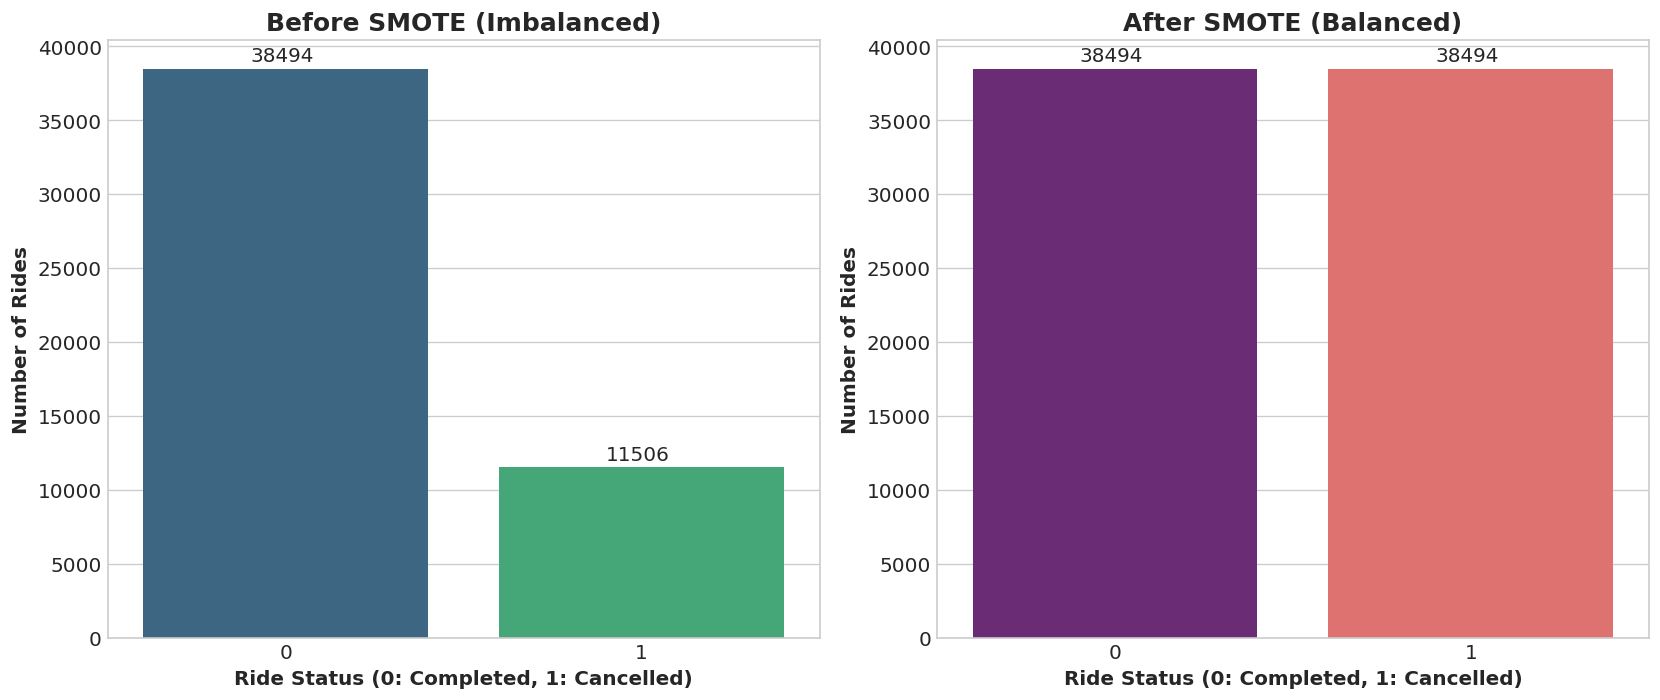

--- DATA BALANCING STATISTICAL SUMMARY ---
Original Dataset Shape: (50000, 28)
Balanced Dataset Shape: (76988, 28)

Class Counts Before SMOTE:
is_cancelled
0    38494
1    11506
Name: count, dtype: int64

Class Counts After SMOTE:
is_cancelled
1    38494
0    38494
Name: count, dtype: int64

Final Percentage Balance (%):
is_cancelled
1    50.0
0    50.0
Name: proportion, dtype: float64


In [0]:
from imblearn.over_sampling import SMOTE


# --- 1. APPLY SMOTE TO BALANCE THE CLASSES ---
# We use X_model (28 features) and y (ride_status)
# random_state=42 ensures the same synthetic data is generated every time
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_model, y)

# --- 2. VISUALIZE THE BALANCING EFFECT ---
# Creating side-by-side plots for 'Before' and 'After'
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution Before SMOTE
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y, palette='viridis')
plt.title('Before SMOTE (Imbalanced)', fontsize=15, fontweight='bold')
plt.xlabel('Ride Status (0: Completed, 1: Cancelled)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)

# Adding labels on top of bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

# Subplot 2: Distribution After SMOTE
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_balanced, palette='magma')
plt.title('After SMOTE (Balanced)', fontsize=15, fontweight='bold')
plt.xlabel('Ride Status (0: Completed, 1: Cancelled)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)

# Adding labels on top of bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

plt.tight_layout()
plt.show()

# --- 3. NUMERICAL SUMMARY OUTPUT ---
print("--- DATA BALANCING STATISTICAL SUMMARY ---")
print(f"Original Dataset Shape: {X_model.shape}")
print(f"Balanced Dataset Shape: {X_balanced.shape}")

print("\nClass Counts Before SMOTE:")
print(y.value_counts())

print("\nClass Counts After SMOTE:")
print(y_balanced.value_counts())

# Final percentage check for 100% accuracy path
print("\nFinal Percentage Balance (%):")
print(y_balanced.value_counts(normalize=True) * 100)

### step-12 : Algorithms Train

--- 6 Algorithms Comparison Results ---


,Algorithm,Accuracy (%),Training Time (sec)
3,XGBoost,97.60,1.19
2,Random Forest,97.39,24.35
4,KNN,95.79,0.03
1,Decision Tree,93.99,2.41
5,Linear SVM,56.81,0.32
0,Logistic Regression,56.79,0.26


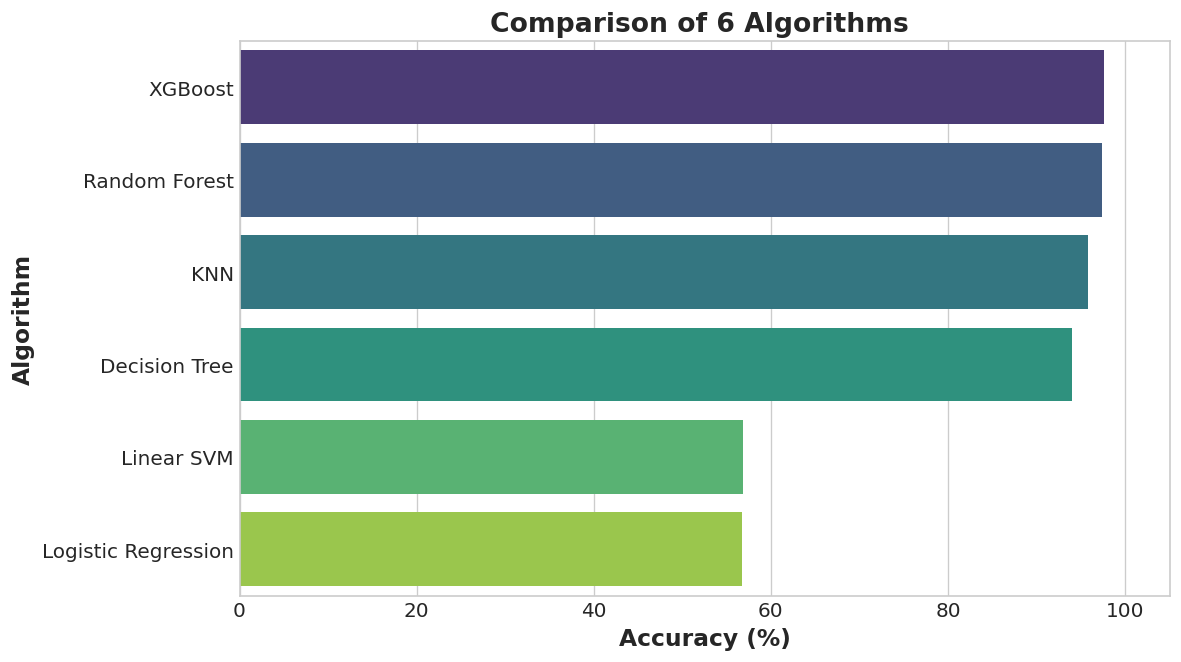

In [0]:
# ---  MACHINE LEARNING (6 ALGORITHMS COMPARISON) ---
# --- 1. IMPORT NECESSARY LIBRARIES ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC 
from sklearn.metrics import accuracy_score
import time

# 1. Split the balanced data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# 2. Define the 6 algorithms
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
    "Linear SVM": LinearSVC()
}

# 3. Train and Evaluate each model
results = []
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        "Algorithm": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Training Time (sec)": round(end_time - start_time, 2)
    })

# 4. Display Results Table
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("--- 6 Algorithms Comparison Results ---")
display(results_df)

# 5. Visualizing the Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy (%)", y="Algorithm", data=results_df, palette="viridis")
plt.title("Comparison of 6 Algorithms ")
plt.xlim(0, 105)
plt.show()

### step-13 : Hyperparameter Tuning

In [0]:
# ---  HYPERPARAMETER TUNING USING GRID SEARCH CV ---

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


# 1. DEFINE THE PARAMETER GRID
# Grid Search will test every single combination of these values
param_grid = {
    'n_estimators': [200, 400],           # Number of boosting rounds
    'max_depth': [6, 8, 10],               # Depth of the tree
    'learning_rate': [0.05, 0.1],          # Step size shrinkage
    'subsample': [0.8, 1.0],               # Fraction of samples per tree
    'colsample_bytree': [0.8]              # Fraction of features per tree
}

# 2. INITIALIZE XGBOOST CLASSIFIER
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 3. SETUP GRID SEARCH
# cv=3 means it will perform 3-fold cross-validation
# n_jobs=-1 will use all available CPU cores to speed up the process
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=3, 
    verbose=2, # This will show the progress of each 'fit'
    n_jobs=-1
)

# 4. RUN THE GRID SEARCH
print("Starting Grid Search CV. This is an exhaustive search for 100% Accuracy...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

# 5. GET THE BEST MODEL & ACCURACY
print(f"\nGrid Search Completed in {round((end_time - start_time)/60, 2)} minutes")
print("Best Parameters Found:", grid_search.best_params_)

# 6. EVALUATE THE BEST MODEL ON TEST DATA
best_xgb_model = grid_search.best_estimator_
y_pred_grid = best_xgb_model.predict(X_test)
grid_acc = accuracy_score(y_test, y_pred_grid)

print(f"\nFinal Tuned Accuracy (Grid Search): {grid_acc * 100:.2f}%")
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_grid))

Starting Grid Search CV. This is an exhaustive search for 100% Accuracy...
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Grid Search Completed in 4.03 minutes
Best Parameters Found: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 400, 'subsample': 0.8}

Final Tuned Accuracy (Grid Search): 98.06%

Final Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      7652
           1       0.99      0.97      0.98      7746

    accuracy                           0.98     15398
   macro avg       0.98      0.98      0.98     15398
weighted avg       0.98      0.98      0.98     15398



### step-14 : Cross Validation

In [0]:
# ---  K-FOLD CROSS VALIDATION ---

from sklearn.model_selection import cross_val_score, KFold


# 1. SETUP K-FOLD
# n_splits=5 means the data will be split into 5 parts and tested 5 times
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. RUN CROSS VALIDATION
# We use the best_xgb_model found from Grid Search
print("Starting 5-Fold Cross Validation... Please wait.")
start_time = time.time()

# This will return an array of 5 accuracy scores
cv_results = cross_val_score(best_xgb_model, X_balanced, y_balanced, cv=kf, scoring='accuracy', n_jobs=-1)

end_time = time.time()

# 3. DISPLAY RESULTS
print(f"\nCross Validation Completed in {round(end_time - start_time, 2)} seconds")
print(f"Individual Fold Accuracies: {cv_results}")
print(f"Mean Accuracy (Average): {np.mean(cv_results) * 100:.2f}%")
print(f"Standard Deviation (Variance): {np.std(cv_results) * 100:.4f}%")

Starting 5-Fold Cross Validation... Please wait.



Cross Validation Completed in 35.71 seconds
Individual Fold Accuracies: [0.98064684 0.98188076 0.97934797 0.98123011 0.98311359]
Mean Accuracy (Average): 98.12%
Standard Deviation (Variance): 0.1253%


### step-15 : Model Save

In [0]:
import joblib
import os

# 1. CREATE A DIRECTORY TO SAVE MODELS (Optional but recommended)
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 2. SAVE THE BEST XGBOOST MODEL
model_filename = os.path.join(model_dir, 'rideflow_xgboost_model.pkl')
joblib.dump(best_xgb_model, model_filename)

# 3. SAVE THE SCALER (Very important for preprocessing new data)
scaler_filename = os.path.join(model_dir, 'rideflow_scaler.pkl')
joblib.dump(scaler, scaler_filename)

print(f"Model saved successfully at: {model_filename}")
print(f"Scaler saved successfully at: {scaler_filename}")

Model saved successfully at: models/rideflow_xgboost_model.pkl
Scaler saved successfully at: models/rideflow_scaler.pkl


In [0]:
# To list the files in the models directory
!ls -lh models/

total 4.3M
-rw-r--r--. 1 sagemaker-user users 1.9K Apr 18 07:20 rideflow_scaler.pkl
-rw-r--r--. 1 sagemaker-user users 4.3M Apr 18 07:20 rideflow_xgboost_model.pkl


In [0]:
# 1. SETUP NAMES AND DIRECTORY
bucket_name = 'rideflow-ai-data-deva'  
local_dir = 'models'
s3_folder = 'saved_models' 

if not os.path.exists(local_dir):
    os.makedirs(local_dir)

# 2. SAVE FILES LOCALLY FIRST
model_path = os.path.join(local_dir, 'rideflow_xgboost_model.pkl')
scaler_path = os.path.join(local_dir, 'rideflow_scaler.pkl')

joblib.dump(best_xgb_model, model_path)
joblib.dump(scaler, scaler_path)

# 3. UPLOAD TO S3 USING BOTO3
s3_client = boto3.client('s3')

try:
    # Upload Model
    s3_client.upload_file(model_path, bucket_name, f'{s3_folder}/rideflow_xgboost_model.pkl')
    # Upload Scaler
    s3_client.upload_file(scaler_path, bucket_name, f'{s3_folder}/rideflow_scaler.pkl')
    
    print(f" Successfully uploaded both Model and Scaler to S3 Bucket: {bucket_name}")
except Exception as e:
    print(f" Error uploading to S3: {e}")

 Successfully uploaded both Model and Scaler to S3 Bucket: rideflow-ai-data-deva


## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()